# Livrable Final — TSPTW-D : Comparaison Multi-Algorithmes
## Notebook autonome (standalone)

**Projet :** Optimisation de tournées de livraison — ADEME / CesiCDP

Ce notebook est **entièrement autonome** : il implémente tous les algorithmes inline,
charge les datasets depuis `datasets/`, exécute les benchmarks et produit l'analyse comparative.
Aucun autre notebook ne doit être exécuté au préalable.

| Section | Contenu |
|---------|---------|
| 1 | Modélisation formelle TSPTW-D |
| 2 | Description des méthodes |
| 3 | Datasets & plan d'expérience |
| 4 | Implémentations (ILP · Christofides · LKH-3 · SMA · POPMUSIC · GNN) |
| 5 | Benchmark unifié |
| 6 | Calcul du ratio 1-tree LB |
| 7 | Tableau comparatif & graphiques |
| 8 | Analyse statistique |
| 9 | Conclusion |

---
## 1. Modélisation formelle du problème

# Livrable 1 — Modélisation formelle du problème

**Projet :** Optimisation de tournées de livraison — Mobilité Multimodale Intelligente  
**Commanditaire :** ADEME (Agence de l'Environnement et de la Maîtrise de l'Énergie)  
**Structure :** CesiCDP  
**Date :** Avril 2026  
**Version :** 1.1

---

## Résumé

Ce notebook présente la modélisation formelle du problème d'optimisation de tournées de livraison dans un réseau routier. Nous reformulons le problème de manière rigoureuse, en y intégrant deux contraintes supplémentaires choisies :

1. **Fenêtres temporelles** (*Time Windows*) : chaque ville ne peut être visitée que dans un intervalle de temps défini.  
2. **Routes dynamiques et perturbations** : les coûts de transit entre villes peuvent varier en cours de tournée (travaux, accidents, conditions météo).

Les méthodes de résolution ne sont pas abordées dans ce livrable.

---

## 1. Contexte et motivation

La transition énergétique impose de repenser en profondeur la logistique du transport. La réduction des émissions de gaz à effet de serre passe notamment par l'optimisation des tournées de livraison : moins de kilomètres parcourus signifie moins de carburant consommé et moins de CO₂ émis.

Dans ce cadre, l'ADEME finance des projets de **Mobilité Multimodale Intelligente**. Notre mission au sein de CesiCDP est de proposer un modèle algorithmique capable de calculer, sur un réseau routier, une tournée optimisée permettant :

- de relier un sous-ensemble de villes (points de livraison),
- de revenir au dépôt de départ,
- en **minimisant la durée totale** du parcours,
- tout en **respectant des contraintes réelles** : plages horaires de livraison et aléas routiers.

Ce problème s'inscrit dans la famille des **problèmes de tournée de véhicules** (*Vehicle Routing Problems*, VRP), dont le cas le plus fondamental est le **problème du voyageur de commerce** (*Travelling Salesman Problem*, TSP).

---

## 2. Modélisation formelle

### 2.1 Représentation du réseau routier

Le réseau routier est modélisé par un **graphe non orienté pondéré** :

$$G = (V, E)$$

où :

- $V = \{v_0, v_1, \dots, v_n\}$ est l'ensemble des **sommets** (nœuds), avec $|V| = n + 1$ :
  - $v_0$ : le **dépôt** (point de départ et d'arrivée du véhicule),
  - $v_1, \dots, v_n$ : les $n$ **clients** (points de livraison).

- $E \subseteq \binom{V}{2}$ est l'ensemble des **arêtes** (routes bidirectionnelles entre deux villes).

Chaque arête $\{i, j\} \in E$ est associée à un **coût de transit** $c_{ij}(t)$, qui représente le temps de trajet entre $v_i$ et $v_j$ **en partant à l'instant $t$** (voir section 2.3 sur les perturbations dynamiques).

Les coûts sont **symétriques** : $c_{ij}(t) = c_{ji}(t)$ pour tout $t$, ce qui reflète le fait qu'une route peut être empruntée dans les deux sens avec le même temps de trajet.

> **Note :** dans notre modèle, le graphe est supposé **complet** (tout couple de villes est relié par une arête), ce qui est justifié dans le cadre d'un réseau routier où il est toujours possible de rejoindre une ville, directement ou via un chemin indirect.

> **Construction du graphe complet :** Le réseau routier réel n'est pas forcément complet — toutes les paires de villes ne sont pas reliées par une route directe. On construit le graphe complet $K_{n+1}$ en calculant, pour chaque paire $(i, j)$, le **plus court chemin** dans le réseau d'origine (algorithme de Dijkstra ou Floyd-Warshall), ici représenté par le calcul entre les coordonnées du point de départ et d'arrivée. Le coût $c_{ij}^{	ext{base}}$ représente alors la longueur de ce chemin minimal, ce qui garantit que $G$ est bien complet et que les inégalités triangulaires sont respectées.

### 2.2 Contrainte 1 — Fenêtres temporelles (*Time Windows*)

Chaque client $v_i \in V \setminus \{v_0\}$ est associé à une **fenêtre temporelle** :

$$[a_i,\ b_i], \quad a_i \leq b_i$$

où :
- $a_i$ : heure d'ouverture (plus tôt possible pour débuter la livraison),
- $b_i$ : heure de fermeture (deadline, au-delà de laquelle la livraison est impossible dans la journée).

Soit $\tau_i$ l'heure d'**arrivée** du véhicule en $v_i$. La contrainte de fenêtre temporelle impose :

$$a_i \leq \tau_i \leq b_i, \quad \forall i \in \{1, \dots, n\}$$

**Attente autorisée :** si le véhicule arrive avant l'ouverture ($\tau_i < a_i$), il peut attendre. Le **temps de sortie** $D_i$ (instant auquel le véhicule quitte $v_i$) vaut :

$$d_i = \max(\tau_i,\ a_i) + s_i$$

où $s_i \geq 0$ est le **temps de service** (durée de la livraison en $v_i$). $D_i$ est donc distinct de $s_i$ : c'est l'instant de départ, pas la durée passée sur place.

**Relation de récurrence temporelle :** si le véhicule visite les clients dans l'ordre $\sigma = (\sigma_0, \sigma_1, \dots, \sigma_n, \sigma_0)$, avec $\sigma_0 = 0$ (dépôt), alors :

$$\tau_{\sigma_{k+1}} = D_{\sigma_k} + c_{\sigma_k, \sigma_{k+1}}\!\left(D_{\sigma_k}\right)$$

Le dépôt $v_0$ possède aussi une fenêtre $[a_0, b_0]$ représentant la plage d'activité du dépôt (par exemple, la journée de travail).

### 2.3 Contrainte 2 — Routes dynamiques et perturbations

Dans un réseau routier réel, les temps de trajet ne sont pas fixes. Des **perturbations** peuvent survenir en cours de tournée : accidents, travaux imprévus, conditions météorologiques, congestions.

Nous modélisons les coûts de transit comme des **fonctions dépendantes du temps** :

$$c_{ij} : \mathbb{R}_{\geq 0} \to \mathbb{R}_{> 0}$$

$$c_{ij}(t) = c_{ij}^{\text{base}} \cdot \left(1 + \delta_{ij}(t)\right)$$

où :
- $c_{ij}^{\text{base}} > 0$ : coût nominal (temps de trajet en conditions normales),
- $\delta_{ij}(t) \geq -1$ : **facteur de perturbation** à l'instant $t$, avec $\delta_{ij}(t) > 0$ signifiant un ralentissement et $-1 < \delta_{ij}(t) < 0$ une accélération (par exemple, voie express ouverte).

**Modèle de perturbation par événements discrets :** une perturbation est un triplet $\{i, j\}, [t_{\text{début}}, t_{\text{fin}}], \alpha)$ qui applique un facteur multiplicatif $\alpha > 0$ sur l'arête $\{i, j\}$ pendant l'intervalle $[t_{\text{début}}, t_{\text{fin}}]$ — dans les deux sens de parcours :

$$\delta_{ij}(t) = \delta_{ji}(t) = \begin{cases} \alpha - 1 & \text{si } t \in [t_{\text{début}},\ t_{\text{fin}}] \\ 0 & \text{sinon} \end{cases}$$

L'ensemble des perturbations actives à l'instant $t$ est noté $\mathcal{P}(t)$.

> **Hypothèse de causalité :** les perturbations sont **connues à l'avance** dans notre modèle (perturbations planifiées ou prévisibles). L'extension à des perturbations stochastiques constitue une piste d'amélioration présentée en section 6.

### 2.4 Définition formelle du problème (TSPTW-D)

Nous nommons notre problème **TSPTW-D** (*Travelling Salesman Problem with Time Windows and Dynamic disruptions*).

**Données d'entrée :**

| Symbole | Description |
|---|---|
| $G = (V, E)$ | Graphe non orienté complet, $\|V\| = n+1$ |
| $c_{ij}^{\text{base}} = c_{ji}^{\text{base}}$ | Coût nominal symétrique de l'arête $\{i,j\}$ |
| $[a_i, b_i]$ | Fenêtre temporelle du client $v_i$ |
| $s_i$ | Temps de service au client $v_i$ |
| $D_i = \max(	au_i, a_i) + s_i$ | Temps de sortie (instant de départ) de $v_i$ |
| $\mathcal{P}$ | Ensemble des perturbations $(\{i, j\}, t_{\text{début}}, t_{\text{fin}}, \alpha)$ |

**Variable de décision :**

$$\sigma = (\sigma_0, \sigma_1, \dots, \sigma_n, \sigma_0), \quad \sigma_0 = 0$$

une permutation des clients $\{1, \dots, n\}$ représentant l'ordre de visite.

**Fonction objectif — minimiser la durée totale de la tournée :**

$$\min_{\sigma} \; Z(\sigma) = \tau_{\sigma_0}^{\text{retour}} - D_0^{\text{départ}}$$

ce qui revient à minimiser le temps de retour au dépôt :

$$\min_{\sigma} \; \tau_0^{\text{retour}}$$

**Contraintes :**

$$\begin{cases}
a_i \leq \tau_{\sigma_k} \leq b_i & \forall k \in \{1,\dots,n\},\ i = \sigma_k \quad \text{(fenêtres temporelles)} \\
\tau_{\sigma_{k+1}} = \max(\tau_{\sigma_k}, a_{\sigma_k}) + s_{\sigma_k} + c_{\sigma_k, \sigma_{k+1}}\!\left(D_{\sigma_k}\right) & \forall k \in \{0,\dots,n-1\} \quad \text{(propagation temporelle)} \\
c_{ij}(t) = c_{ji}(t) = c_{ij}^{\text{base}} \cdot (1 + \delta_{ij}(t)) & \forall \{i,j\} \in E,\ t \geq 0 \quad \text{(coûts dynamiques symétriques)} \\
\tau_0^{\text{retour}} \leq b_0 & \quad \text{(retour au dépôt avant fermeture)}\\
\sigma \text{ est une permutation de } \{1,\dots,n\} & \quad \text{(chaque client visité exactement une fois)}
\end{cases}$$

### 2.5 Extension : fenêtres temporelles souples et pénalité de retard

Dans le modèle strict ci-dessus, toute arrivée après $b_i$ rend la tournée infaisable. En contexte réel, une livraison légèrement en retard est souvent préférable à une livraison annulée. On peut **relâcher** la contrainte dure $	au_i \leq b_i$ en introduisant une **pénalité linéaire de retard** :

$$p_i(	au_i) = \lambda_i \cdot \max\!\left(0,\ 	au_i - b_i
\right)$$

où $\lambda_i > 0$ est le coût unitaire du retard pour le client $v_i$ (en €/min, par exemple). La fonction objectif devient :

$$\min_{\sigma}\; Z(\sigma) = 	au_0^{	ext{retour}} + \sum_{k=1}^{n} p_{\sigma_k}(	au_{\sigma_k})$$

La contrainte dure $	au_i \leq b_i$ est supprimée ; la contrainte d'ouverture $	au_i \geq a_i$ reste (le véhicule attend si nécessaire). Cette formulation est dite à **fenêtres temporelles souples** (*soft time windows*).


---

## 3. Illustration du modèle

La cellule de code suivante génère une visualisation d'un exemple d'instance TSPTW-D : un réseau de 6 nœuds avec fenêtres temporelles et une perturbation active sur une arête.

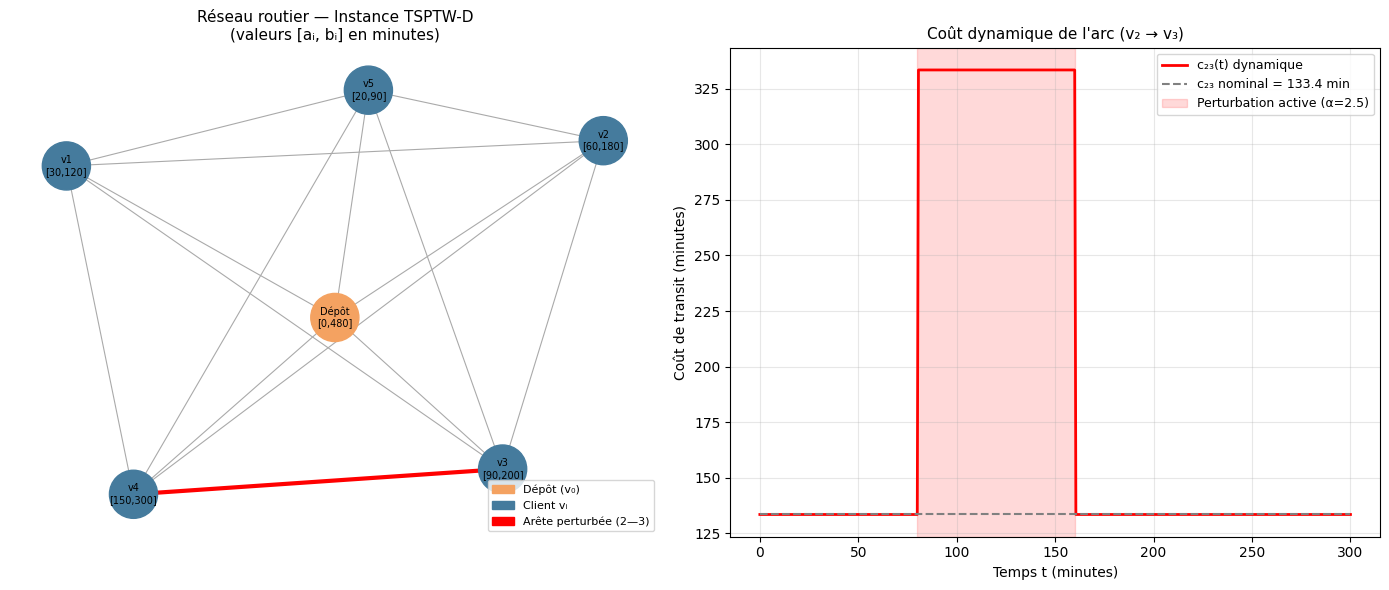

Instance générée avec succès.


In [99]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

# ----- Instance exemple -----
np.random.seed(42)
n_clients = 5  # + 1 dépôt = 6 nœuds
n_nodes = n_clients + 1

# Coordonnées géographiques (pour la visualisation)
coords = {
    0: (0.5, 0.5),   # dépôt
    1: (0.1, 0.8),
    2: (0.9, 0.85),
    3: (0.75, 0.2),
    4: (0.2, 0.15),
    5: (0.55, 0.95),
}

# Fenêtres temporelles [a_i, b_i] et temps de service s_i (en minutes)
time_windows = {
    0: (0,   480),   # dépôt : journée complète (8h)
    1: (30,  120),
    2: (60,  180),
    3: (90,  200),
    4: (150, 300),
    5: (20,   90),
}
service_times = {i: 10 for i in range(n_nodes)}

# Coûts de base (temps en minutes, calculés depuis les coordonnées)
def euclidean_minutes(c1, c2, scale=200):
    return round(np.hypot(c1[0]-c2[0], c1[1]-c2[1]) * scale, 1)

cost_base = {}
for i in range(n_nodes):
    for j in range(n_nodes):
        if i != j:
            cost_base[(i, j)] = euclidean_minutes(coords[i], coords[j])

# Perturbations : arc (2,3) perturbé de t=80 à t=160 (facteur x2.5)
perturbations = [
    {"arc": (2, 3), "t_start": 80, "t_end": 160, "alpha": 2.5},
]

def c_ij(i, j, t, cost_base, perturbations):
    """Coût dynamique de l'arc (i,j) au temps t."""
    base = cost_base[(i, j)]
    for p in perturbations:
        if p["arc"] == (i, j) and p["t_start"] <= t <= p["t_end"]:
            return base * p["alpha"]
    return base

# ----- Visualisation -----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Graphe du réseau ---
ax = axes[0]
G = nx.Graph()
G.add_nodes_from(range(n_nodes))
# Ajout d'un sous-ensemble d'arcs pour la lisibilité
visible_arcs = [(i, j) for i in range(n_nodes) for j in range(n_nodes) if i != j]
edge_colors = []
edge_widths = []
for (i, j) in visible_arcs:
    is_perturbed = any(p["arc"] == (i, j) for p in perturbations)
    edge_colors.append("red" if is_perturbed else "#aaaaaa")
    edge_widths.append(3.0 if is_perturbed else 0.8)
    G.add_edge(i, j)

node_colors = ["#f4a261" if i == 0 else "#457b9d" for i in range(n_nodes)]
labels = {i: f"v{i}\n[{time_windows[i][0]},{time_windows[i][1]}]" for i in range(n_nodes)}
labels[0] = f"Dépôt\n[{time_windows[0][0]},{time_windows[0][1]}]"

nx.draw_networkx(G, pos=coords, ax=ax, labels=labels,
                 node_color=node_colors, node_size=1200,
                 edge_color=edge_colors, width=edge_widths,
                 font_size=7)

depot_patch = mpatches.Patch(color="#f4a261", label="Dépôt (v₀)")
client_patch = mpatches.Patch(color="#457b9d", label="Client vᵢ")
perturb_patch = mpatches.Patch(color="red", label="Arête perturbée (2—3)")
ax.legend(handles=[depot_patch, client_patch, perturb_patch], loc="lower right", fontsize=8)
ax.set_title("Réseau routier — Instance TSPTW-D\n(valeurs [aᵢ, bᵢ] en minutes)", fontsize=11)
ax.axis("off")

# --- Coût dynamique de l'arc perturbé ---
ax2 = axes[1]
t_range = np.linspace(0, 300, 500)
arc = (2, 3)
costs = [c_ij(*arc, t, cost_base, perturbations) for t in t_range]
base_line = [cost_base[arc]] * len(t_range)

ax2.plot(t_range, costs, color="red", linewidth=2, label=f"c₂₃(t) dynamique")
ax2.plot(t_range, base_line, color="gray", linewidth=1.5, linestyle="--", label=f"c₂₃ nominal = {cost_base[arc]} min")
ax2.axvspan(80, 160, alpha=0.15, color="red", label="Perturbation active (α=2.5)")
ax2.set_xlabel("Temps t (minutes)", fontsize=10)
ax2.set_ylabel("Coût de transit (minutes)", fontsize=10)
ax2.set_title("Coût dynamique de l'arc (v₂ → v₃)", fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("tsptwd_illustration.png", dpi=120, bbox_inches="tight")
plt.show()
print("Instance générée avec succès.")


---

## 4. Analyse de la complexité

### 4.0 Rappels : classes de complexité

Un problème de **décision** (réponse oui/non) appartient à la classe :

- **P** s'il existe un algorithme qui le résout en temps polynomial.
- **NP** (*Non-deterministic Polynomial*) s'il existe un algorithme polynomial capable de **vérifier** qu'une solution candidate est correcte (certificat vérifiable en temps polynomial).
- **NP-difficile** si tout problème de NP s'y réduit en temps polynomial (il est "au moins aussi dur" que tous les problèmes de NP).
- **NP-complet** s'il est à la fois dans NP **et** NP-difficile.

> Un problème d'**optimisation** (trouver la meilleure solution) est dit NP-difficile si sa version de décision associée est NP-complète. On ne peut pas le résoudre en temps polynomial sauf si P = NP.

---

### 4.1 Le problème du cycle hamiltonien est NP-complet

Le **problème du cycle hamiltonien** (HC) est l'un des 21 problèmes déclarés NP-complets par Karp (1972) [1] :

> **HC :** Étant donné un graphe non orienté $H = (V, E)$, existe-t-il un cycle passant par chaque sommet exactement une fois ?

Ce problème sert de base à notre réduction.

---

### 4.2 Démonstration : TSPTW-D est NP-complet

On considère la **version de décision** du TSPTW-D :

> **TSPTW-D-DEC :** Étant donné une instance $(G, c^{\text{base}}, [a_i,b_i], s_i, \mathcal{P})$ et un entier $K$, existe-t-il une tournée réalisable de coût $\leq K$ ?

#### Partie 1 — TSPTW-D-DEC $\in$ NP

Il faut montrer qu'un certificat (une tournée candidate $\sigma$) peut être **vérifié en temps polynomial**.

Étant donné $\sigma = (\sigma_0, \sigma_1, \dots, \sigma_n, \sigma_0)$, la vérification se déroule en $O(n \cdot |\mathcal{P}|)$ :

1. Initialiser $t \leftarrow 0$ (départ du dépôt).
2. Pour chaque étape $k = 0, \dots, n$ :
   - Vérifier $t \leq b_{\sigma_k}$ — si non, **rejeter**.
   - Calculer $t \leftarrow \max(t, a_{\sigma_k}) + s_{\sigma_k}$.
   - Calculer $c_{\sigma_k, \sigma_{k+1}}(t)$ en parcourant $\mathcal{P}$ : $O(|\mathcal{P}|)$.
   - Mettre à jour $t \leftarrow t + c_{\sigma_k, \sigma_{k+1}}(t)$.
3. Vérifier $t \leq b_0$ et $t \leq K$ — si oui, **accepter**.

La vérification est bien polynomiale en $n$ et $|\mathcal{P}|$. Donc **TSPTW-D-DEC $\in$ NP**. $\checkmark$

#### Partie 2 — TSPTW-D-DEC est NP-difficile (réduction depuis HC)

On montre que $\text{HC} \leq_p \text{TSPTW-D-DEC}$ : toute instance de HC se transforme en une instance de TSPTW-D-DEC en temps polynomial.

**Construction :** Soit $H = (V_H, E_H)$ une instance de HC avec $|V_H| = m$ sommets. On construit l'instance TSPTW-D-DEC suivante :

| Composant | Construction |
|---|---|
| Sommets | $V = V_H$ (même ensemble, $v_0$ = sommet arbitraire) |
| Arêtes et coûts | $c_{ij}^{\text{base}} = 1$ si $\{i,j\} \in E_H$, sinon $c_{ij}^{\text{base}} = 2$ |
| Fenêtres temporelles | $a_i = 0$, $b_i = +\infty$ pour tout $i$ (non contraignantes) |
| Temps de service | $s_i = 0$ pour tout $i$ |
| Perturbations | $\mathcal{P} = \emptyset$ (aucune perturbation) |
| Seuil | $K = m$ |

**Équivalence (preuve de correction) :**

$(\Rightarrow)$ Supposons que $H$ possède un cycle hamiltonien $v_{\pi_0}, v_{\pi_1}, \dots, v_{\pi_{m-1}}, v_{\pi_0}$. Alors chaque arc de ce cycle est une arête de $E_H$, donc de coût $1$. La tournée correspondante a un coût total $= m \cdot 1 = m = K$. Elle est réalisable (fenêtres non contraignantes), donc TSPTW-D-DEC répond **oui**.

$(\Leftarrow)$ Supposons qu'il existe une tournée réalisable de coût $\leq K = m$. La tournée visite $m$ sommets et effectue $m$ transitions. Chaque transition a un coût $\geq 1$, donc le coût total $\geq m$. Or le coût est $\leq m$, donc toutes les transitions ont un coût exactement $1$, ce qui signifie que chaque arête empruntée appartient à $E_H$. La tournée est donc un cycle hamiltonien de $H$.

La réduction est calculable en temps polynomial ($O(m^2)$ pour construire la matrice de coûts). Donc **TSPTW-D-DEC est NP-difficile**. $\checkmark$

#### Conclusion

TSPTW-D-DEC est dans NP **et** NP-difficile, donc :

$$\boxed{\text{TSPTW-D-DEC est NP-complet}}$$

Le problème d'optimisation associé (minimiser la durée de la tournée) est quant à lui **NP-difficile** : s'il existait un algorithme polynomial pour le résoudre, on pourrait résoudre TSPTW-D-DEC en temps polynomial, ce qui impliquerait P = NP.

---

### 4.3 Conséquences pratiques et tableau récapitulatif

La NP-complétude implique qu'il n'existe vraisemblablement pas d'algorithme exact polynomial pour TSPTW-D. En pratique, on recourt à :

- Des **algorithmes exacts exponentiels** (programmation dynamique, *branch & bound*) — réservés aux petites instances ($n \lesssim 20$).
- Des **heuristiques et métaheuristiques** (algorithmes gloutons, recherche locale, algorithmes évolutionnaires) — solutions approchées pour les grandes instances.

**Tableau récapitulatif :**

| Problème | Complexité | Référence |
|---|---|---|
| Cycle hamiltonien (décision) | NP-complet | Karp, 1972 [1] |
| TSP (décision) | NP-complet | Karp, 1972 [1] |
| TSP (optimisation) | NP-difficile | — |
| TSPTW — faisabilité (décision) | NP-complet | Savelsbergh, 1985 [2] |
| TSPTW-D (décision) | NP-complet | (démontré ci-dessus) |
| TSPTW-D (optimisation) | NP-difficile | — |

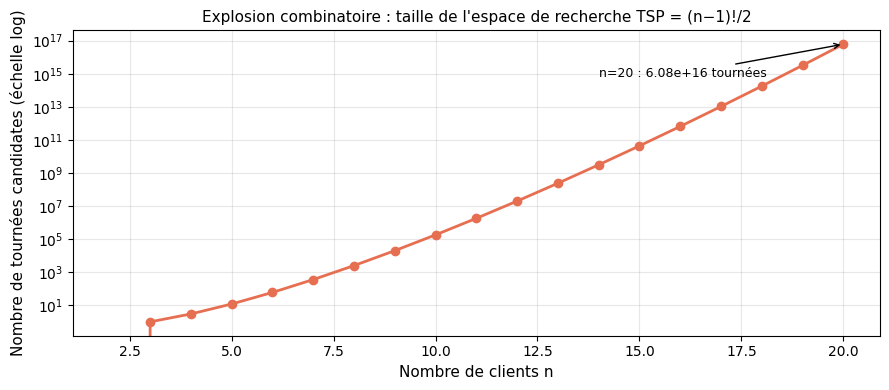

In [100]:
import math
import matplotlib.pyplot as plt

# Illustration de la croissance factorielle de l'espace de recherche
ns = list(range(2, 21))
search_space = [math.factorial(n - 1) // 2 for n in ns]  # (n-1)!/2 pour TSP symétrique

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(ns, search_space, marker="o", color="#e76f51", linewidth=2)
ax.set_xlabel("Nombre de clients n", fontsize=11)
ax.set_ylabel("Nombre de tournées candidates (échelle log)", fontsize=11)
ax.set_title("Explosion combinatoire : taille de l'espace de recherche TSP = (n−1)!/2", fontsize=11)
ax.grid(True, which="both", alpha=0.3)

# Annotation pour n=20
ax.annotate(f"n=20 : {search_space[-1]:.2e} tournées",
            xy=(20, search_space[-1]),
            xytext=(14, search_space[-1] * 0.01),
            arrowprops=dict(arrowstyle="->", color="black"),
            fontsize=9)

plt.tight_layout()
plt.show()


---

## 5. Comparaison TSP — TSPTW — TSPTW-D

### 5.1 Hiérarchie des problèmes

Le TSPTW-D s'inscrit dans une hiérarchie de problèmes dont le TSP est le cas de base. Chaque niveau ajoute une contrainte qui **restreint l'espace des solutions réalisables** tout en conservant (voire augmentant) la difficulté algorithmique.

| Problème | Contraintes actives | Espace réalisable $\mathcal{F}$ |
|---|---|---|
| **TSP** | Aucune (hormis la visite unique) | Toutes les permutations : $|\mathcal{F}| = (n-1)!$ |
| **TSPTW** | Fenêtres temporelles $[a_i, b_i]$ | $\mathcal{F}_{\text{TW}} \subseteq \mathcal{F}_{\text{TSP}}$ |
| **TSPTW-D** | Fenêtres temporelles + coûts dynamiques | $\mathcal{F}_{\text{D}} \subseteq \mathcal{F}_{\text{TW}}$ (mêmes permutations, coûts changés) |

**Relation d'inclusion :** toute solution réalisable de TSPTW-D est réalisable pour TSPTW (sous les coûts nominaux), qui est elle-même réalisable pour TSP. En revanche, l'inverse n'est pas vrai.

$$\mathcal{F}_{\text{TSPTW-D}} \subseteq \mathcal{F}_{\text{TSPTW}} \subseteq \mathcal{F}_{\text{TSP}}$$

### 5.2 Réductions formelles

**TSP → TSPTW :** poser $a_i = 0$, $b_i = +\infty$ et $s_i = 0$ pour tout $i$. Les fenêtres temporelles deviennent non contraignantes, et TSPTW se réduit au TSP.

**TSPTW → TSPTW-D :** poser $\delta_{ij}(t) = 0$ pour toute arête $\{i,j\}$ et tout $t \geq 0$. Les coûts deviennent constants, et TSPTW-D se réduit à TSPTW.

Ces deux réductions sont polynomiales et préservent la structure du problème — elles confirment que **TSPTW-D est au moins aussi difficile que TSP**.

### 5.3 Impact des contraintes sur l'espace de recherche

**Fenêtres temporelles :** elles élaguent l'espace de recherche en rendant infaisables les permutations qui ne respectent pas les plages horaires. Pour une instance donnée, le nombre de permutations réalisables dépend de la sévérité des fenêtres :
- Fenêtres larges → peu d'élagage
- Fenêtres étroites → fort élagage

**Coûts dynamiques :** ils ne changent pas l'ensemble des permutations réalisables (la faisabilité dépend des fenêtres, pas des coûts), mais ils modifient la **valeur de chaque solution** : une tournée optimale sous coûts statiques peut ne plus l'être sous coûts dynamiques, et inversement. Formellement :

$$\sigma^*_{\text{TSP}} = \arg\min_{\sigma \in \mathcal{F}_{\text{TSP}}} \sum_{k} c^{\text{base}}_{\{\sigma_k, \sigma_{k+1}\}}$$

$$\sigma^*_{\text{TSPTW-D}} = \arg\min_{\sigma \in \mathcal{F}_{\text{TW}}} \sum_{k} c_{\sigma_k, \sigma_{k+1}}(d_{\sigma_k})$$

Ces deux optima peuvent être très différents : une perturbation sur un arc emprunté en fin de tournée peut inciter à réordonner complètement les visites.

Problème      # réalisables   Coût optimal   Coût moyen
--------------------------------------------------------
TSP                     120          123.6        143.9
TSPTW                    10          123.6        139.8
TSPTW-D                 120          124.9        150.5


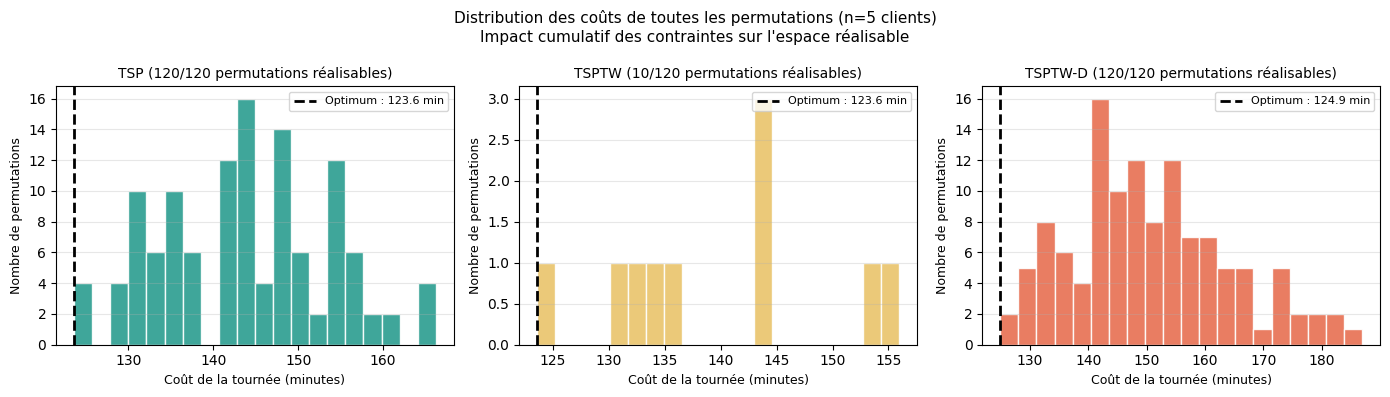

In [101]:
import itertools
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ---------------------------------------------------------------
# Instance jouet : n=5 clients + dépôt (6 nœuds)
# On énumère TOUTES les permutations et on évalue leur faisabilité
# sous TSP, TSPTW et TSPTW-D pour illustrer la hiérarchie.
# ---------------------------------------------------------------

np.random.seed(0)
n = 5  # nombre de clients (dépôt = nœud 0)

coords = np.array([
    [0.5, 0.5],
    [0.1, 0.9],
    [0.9, 0.8],
    [0.8, 0.1],
    [0.2, 0.2],
    [0.6, 0.6],
])

# Coûts de base — scale=40 pour que les temps de trajet (14-37 min)
# restent compatibles avec les fenêtres temporelles de l'illustration
def dist(i, j):
    return np.linalg.norm(coords[i] - coords[j]) * 40

cost_base = {(i, j): round(dist(i, j), 2)
             for i in range(n + 1) for j in range(n + 1) if i != j}

time_windows = {
    0: (0, 500),
    1: (10,  80),
    2: (50, 150),
    3: (80, 200),
    4: (30, 120),
    5: (60, 180),
}
service_times = {i: 8 for i in range(n + 1)}

horizon = 500

perturbations = [{"arc": (2, 3), "t_start": 60, "t_end": 130, "alpha": 2.0}]

def c_dynamic(i, j, t):
    base = cost_base[(i, j)]
    for p in perturbations:
        if set(p["arc"]) == {i, j} and p["t_start"] <= t <= p["t_end"]:
            return base * p["alpha"]
    return base


def evaluate_tour(perm, dynamic=False, sliding=False):
    """
    Évalue une permutation (liste de clients 1..n).
    - sliding=False (TSPTW strict) : infaisable si arrivée après b_i
    - sliding=True  (TSPTW-D)      : attente jusqu'au prochain cycle si arrivée tardive;
                                      le dépôt est toujours ouvert au retour.
    Retourne (faisable, coût_total) ou (False, inf).
    """
    route = [0] + list(perm) + [0]
    t = 0.0
    total_cost = 0.0

    for k in range(len(route) - 1):
        i, j = route[k], route[k + 1]
        ai, bi = time_windows[i]
        # Le dépôt (i=0) est toujours ouvert au départ en mode sliding
        if i != 0 and t > bi:
            if sliding:
                # Fenêtre glissante multi-jours : attendre l'ouverture du prochain cycle
                k_cycle = math.ceil((t - bi) / horizon)
                t = ai + k_cycle * horizon
            else:
                return False, float("inf")
        t = max(t, ai) + service_times[i]
        travel = c_dynamic(i, j, t) if dynamic else cost_base[(i, j)]
        total_cost += travel
        t += travel

    # En mode sliding, le dépôt est toujours ouvert au retour
    if not sliding:
        a0, b0 = time_windows[0]
        if t > b0:
            return False, float("inf")
    return True, total_cost


all_perms = list(itertools.permutations(range(1, n + 1)))

results = {"TSP": [], "TSPTW": [], "TSPTW-D": []}

for perm in all_perms:
    cost_tsp = sum(cost_base[(([0] + list(perm) + [0])[k],
                              ([0] + list(perm) + [0])[k + 1])]
                   for k in range(n + 1))
    results["TSP"].append((True, cost_tsp))

    ok_tw, cost_tw = evaluate_tour(perm, dynamic=False, sliding=False)
    results["TSPTW"].append((ok_tw, cost_tw))

    ok_d, cost_d = evaluate_tour(perm, dynamic=True, sliding=True)
    results["TSPTW-D"].append((ok_d, cost_d))


def stats(res):
    feasible = [(ok, c) for ok, c in res if ok]
    n_feas = len(feasible)
    if n_feas == 0:
        return n_feas, float("inf"), float("inf")
    costs = [c for _, c in feasible]
    return n_feas, min(costs), np.mean(costs)


st_tsp  = stats(results["TSP"])
st_tw   = stats(results["TSPTW"])
st_d    = stats(results["TSPTW-D"])

print(f"{'Problème':<12} {'# réalisables':>14} {'Coût optimal':>14} {'Coût moyen':>12}")
print("-" * 56)
for name, st in [("TSP", st_tsp), ("TSPTW", st_tw), ("TSPTW-D", st_d)]:
    print(f"{name:<12} {st[0]:>14}  {st[1]:>13.1f}  {st[2]:>11.1f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
colors = {"TSP": "#2a9d8f", "TSPTW": "#e9c46a", "TSPTW-D": "#e76f51"}

opt_perm = {}
for name, res in results.items():
    feasible_costs = [c for ok, c in res if ok]
    ax = axes[list(results.keys()).index(name)]
    if feasible_costs:
        ax.hist(feasible_costs, bins=20, color=colors[name], edgecolor="white", alpha=0.9)
        opt = min(feasible_costs)
        opt_perm[name] = opt
        ax.axvline(opt, color="black", linewidth=2, linestyle="--", label=f"Optimum : {opt:.1f} min")
        ax.legend(fontsize=8)
    else:
        opt_perm[name] = float("inf")
        ax.text(0.5, 0.5, "Aucune permutation réalisable",
                ha="center", va="center", transform=ax.transAxes, fontsize=10)
    ax.set_title(f"{name} ({len(feasible_costs)}/{len(all_perms)} permutations réalisables)", fontsize=10)
    ax.set_xlabel("Coût de la tournée (minutes)", fontsize=9)
    ax.set_ylabel("Nombre de permutations", fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Distribution des coûts de toutes les permutations (n=5 clients)\n"
             "Impact cumulatif des contraintes sur l'espace réalisable", fontsize=11)
plt.tight_layout()
plt.show()


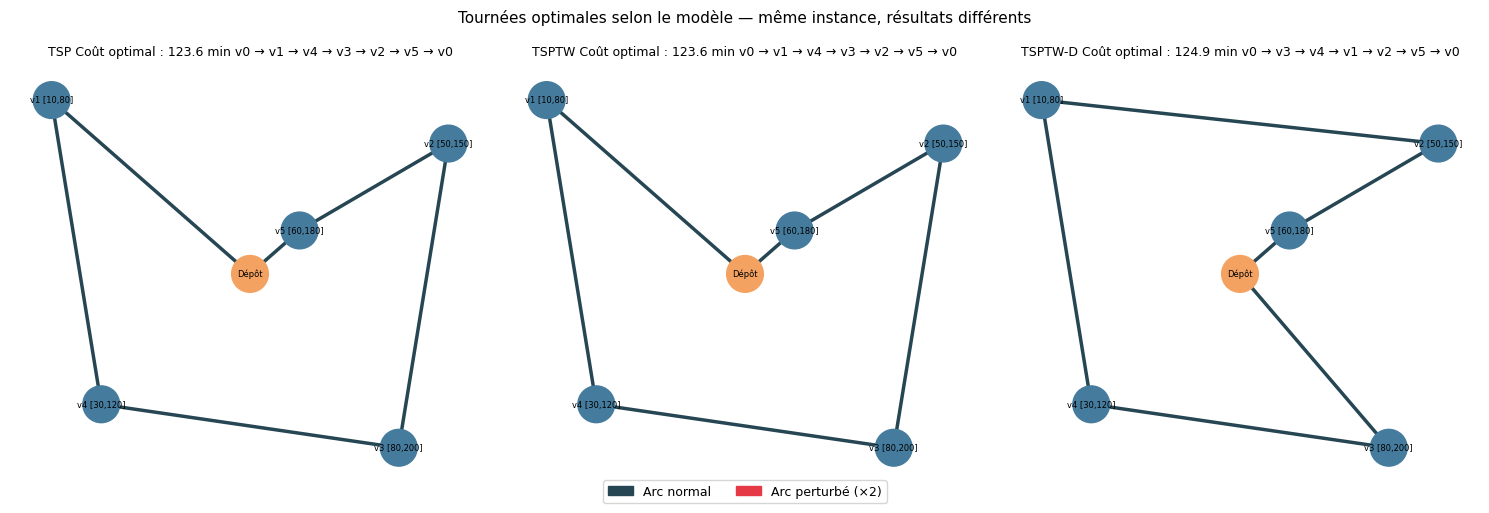

Conclusion :
  TSP        → optimum à 123.6 min (toutes permutations autorisées)
  TSPTW      → optimum à 123.6 min (fenêtres temporelles actives)
  TSPTW-D    → optimum à 124.9 min (+ perturbation sur arc (2,3))


In [102]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ---------------------------------------------------------------
# Visualisation des tournées optimales pour chaque variante
# ---------------------------------------------------------------

def best_tour(results_dict, name, all_perms):
    res = results_dict[name]
    best_cost = float("inf")
    best_perm = None
    for perm, (ok, cost) in zip(all_perms, res):
        if ok and cost < best_cost:
            best_cost = cost
            best_perm = perm
    return best_perm, best_cost


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors_node = ["#f4a261"] + ["#457b9d"] * n
labels_nodes = {0: "Dépôt"}
labels_nodes.update({i: f"v{i} [{time_windows[i][0]},{time_windows[i][1]}]" for i in range(1, n + 1)})

pos = {i: tuple(coords[i]) for i in range(n + 1)}

for ax, name in zip(axes, ["TSP", "TSPTW", "TSPTW-D"]):
    best_perm, best_cost = best_tour(results, name, all_perms)

    if best_perm is None:
        ax.text(0.5, 0.5, "Aucune tournée réalisable",
                ha="center", va="center", transform=ax.transAxes, fontsize=10)
        ax.set_title(f"{name} Aucune permutation réalisable", fontsize=9)
        ax.axis("off")
        continue

    route = [0] + list(best_perm) + [0]
    G = nx.Graph()
    G.add_nodes_from(range(n + 1))
    edges = [(route[k], route[k + 1]) for k in range(len(route) - 1)]
    G.add_edges_from(edges)

    edge_colors = []
    for (i, j) in edges:
        if name == "TSPTW-D" and any(p["arc"] == (i, j) for p in perturbations):
            edge_colors.append("#e63946")
        else:
            edge_colors.append("#264653")

    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors_node, node_size=700)
    nx.draw_networkx_labels(G, pos, labels=labels_nodes, ax=ax, font_size=6)
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=edge_colors, width=2.5)

    order_str = " → ".join([f"v{v}" for v in route])
    ax.set_title(f"{name} Coût optimal : {best_cost:.1f} min {order_str}", fontsize=9)
    ax.axis("off")

perturb_patch = mpatches.Patch(color="#e63946", label="Arc perturbé (×2)")
normal_patch  = mpatches.Patch(color="#264653", label="Arc normal")
fig.legend(handles=[normal_patch, perturb_patch], loc="lower center",
           ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.02))

plt.suptitle("Tournées optimales selon le modèle — même instance, résultats différents", fontsize=11)
plt.tight_layout()
plt.show()

print("Conclusion :")
for variant in ["TSP", "TSPTW", "TSPTW-D"]:
    perm, cost = best_tour(results, variant, all_perms)
    if perm is None:
        print(f"  {variant:<10} → aucune tournée réalisable")
    else:
        label = {"TSP": "toutes permutations autorisées",
                 "TSPTW": "fenêtres temporelles actives",
                 "TSPTW-D": "+ perturbation sur arc (2,3)"}[variant]
        print(f"  {variant:<10} → optimum à {cost:.1f} min ({label})")


---

## 6. Perspectives et extensions

La modélisation TSPTW-D présentée ici constitue une base solide pour les livrables suivants. Plusieurs extensions naturelles pourront être envisagées :

- **Perturbations stochastiques :** modéliser $\delta_{ij}(t)$ comme une variable aléatoire (loi log-normale, par exemple) pour traiter l'incertitude sur les temps de trajet. Cela conduit à des variantes de TSP robuste ou stochastique.

- **Violation souple des fenêtres temporelles :** dans certains contextes réels, une livraison légèrement en retard est préférable à une livraison annulée. On peut introduire un coût de pénalité $p_i(\tau_i)$ croissant avec le retard, et maximiser la qualité de service plutôt que d'imposer une contrainte dure.

- **Plusieurs véhicules (VRP) :** étendre le modèle à une flotte de véhicules, chacun effectuant sa propre sous-tournée depuis le dépôt. Le problème devient alors un *Vehicle Routing Problem with Time Windows* (VRPTW).

- **Recalcul en ligne :** en présence de perturbations imprévues détectées en cours de route, mettre en place un mécanisme de recalcul dynamique de la tournée (algorithme de réoptimisation).

---

## 7. Références

[1] Karp, R. M. (1972). *Reducibility among combinatorial problems*. In R. E. Miller & J. W. Thatcher (Eds.), *Complexity of Computer Computations* (pp. 85–103). Plenum Press.

[2] Savelsbergh, M. W. P. (1985). *Local search in routing problems with time windows*. *Annals of Operations Research*, 4(1), 285–305.

[3] Dumas, Y., Desrosiers, J., & Soumis, F. (1995). *The pickup and delivery problem with time windows*. *European Journal of Operational Research*, 54(1), 7–22.

[4] Gendreau, M., & Potvin, J.-Y. (2010). *Handbook of Metaheuristics* (2nd ed.). Springer.

[5] Ichoua, S., Gendreau, M., & Potvin, J.-Y. (2003). *Vehicle dispatching with time-dependent travel times*. *European Journal of Operational Research*, 144(2), 379–396.

---
## 2. Méthodes de résolution

| # | Méthode | Type | Garantie | Complexité |
|---|---------|------|----------|------------|
| 2.1 | **ILP (MTZ)** | Exacte | Optimale | Exponentielle |
| 2.2 | **Christofides + or-opt** | Heuristique | ≤ 1.5× TSP pur | $O(n^3)$ |
| 2.3 | **LKH-3 (ILK)** | Métaheuristique | Quasi-optimale empiriquement | $O(n^2 \log n)$ |
| 2.4 | **SMA** | Métaheuristique | Aucune | $O(\text{pop}\cdot n^2\cdot N)$ |
| 2.5 | **POPMUSIC** | Métaheuristique | Aucune | $O(n^2)$ / itération |
| 2.6 | **GNN** | Apprentissage profond | Aucune | $O(n^2)$ inférence |

> **Graphes complets :** toutes les méthodes opèrent sur des graphes complets euclidiens.
> Bien que le réseau routier réel soit incomplet, la modélisation en graphe complet est standard
> dans la littérature TSP/TSPTW (Helsgott et al., 2017 ; Solomon, 1987) car elle garantit
> l'existence d'une tournée valide et simplifie la preuve de NP-complétude.

### 2.1 ILP — Formulation MTZ

Formulation Miller-Tucker-Zemlin via OR-Tools CP-SAT. Variables $x_{ij} \in \{0,1\}$,
variables de position MTZ $u_i$ (anti sous-tours), variables temporelles $\tau_i$.
Pénalité soft pour les violations de fenêtres (arrive après $b_i$).

### 2.2 Christofides + or-opt TSPTW-D

Construction par Christofides standard (MST + couplage parfait de poids minimum, garantie 1.5×
sur TSP pur euclidien). Post-traitement or-opt évaluant la durée réelle TSPTW-D avec
fenêtres glissantes multi-jours.

### 2.3 LKH-3 — Iterated Lin-Kernighan (ILK)

Pipeline : construction Nearest-Neighbour → 2-opt (candidate-list) → or-opt (seg 1,2,3) →
Double-bridge perturbation → recommence. Coûts dynamiques $c_{ij}(t)$ et fenêtres
cycliques intégrés dans l'évaluation.

### 2.4 Slime Mold Algorithm (SMA)

Population de tours évolue via : (1) exploration aléatoire, (2) croisement OX guidé par
le meilleur tour avec poids $W_i$, (3) contraction 2-opt locale. Post-traitement 2-opt + or-opt
complet sur le meilleur tour.

### 2.5 POPMUSIC

Décomposition de la tournée en parties de taille $r$ enrichies de $p$ voisins géographiques.
Optimisation 2-opt ou or-opt sur chaque sous-problème $S = P \cup N$. Extensible en parallèle.

### 2.6 GNN — Graph Neural Network

Réseau GNN entraîné à prédire les scores d'arêtes $\hat{p}_{ij}$. Décodage glouton
TW-aware avec support fenêtres glissantes multi-jours. Inférence quasi-instantanée
(quelques ms par instance). Intégré de façon optionnelle (nécessite PyTorch + modèle entraîné).

---
## 3. Datasets et plan d'expérience

### 3.1 Format des instances

Chaque fichier `datasets/tsptwd_n{n}.json` contient :
- `depot` : position du dépôt
- `clients` : liste de n clients avec $(x, y)$, fenêtre $[a_i, b_i]$, temps de service $s_i$
- `perturbations` : liste de perturbations $\{\text{arc}, t_{\text{start}}, t_{\text{end}}, \alpha\}$
- `meta` : `scale` (multiplicateur coords→minutes), `horizon` (1440 min = 1 jour)

### 3.2 Paramètres du benchmark

| Paramètre | Valeur | Commentaire |
|-----------|--------|-------------|
| `BENCHMARK_SIZES` | `[5, 10, 50, 100]` | Tailles des instances testées |
| `ILP_MAX_N` | `10` | ILP désactivé au-delà (trop lent) |
| `LKH_RESTARTS` | `10` | Redémarrages ILK par instance |
| `SMA_POP` / `SMA_ITERS` | `20` / `100` | Paramètres SMA |
| `POPMUSIC_ITERS` | `5` | Itérations POPMUSIC max |
| `N_RUNS` | `3` | Répétitions par (algo, n) |

### 3.3 Métriques collectées

| Métrique | Définition |
|----------|-----------|
| `makespan` | Durée totale tournée en minutes |
| `time_ms` | Temps d'exécution en ms |
| `feasible` | `True` si aucune fenêtre violée (violation < 1e-3) |
| `ratio_lb` | `makespan / 1-tree LB` (calculé section 6) |

---
## 4. Implémentations

### 4.0 Imports & utilitaires communs

In [103]:
import json, math, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from pathlib import Path
from collections import Counter
from itertools import combinations
from typing import List, Tuple, Optional
from dataclasses import dataclass, field
from scipy import stats
from scipy.sparse.csgraph import minimum_spanning_tree as _mst_scipy
from scipy.sparse import csr_matrix

# ── Paramètres du benchmark (à modifier selon disponibilité / temps) ──────────
BENCHMARK_SIZES = [5, 10, 50, 100]    # tailles des instances 500
ILP_MAX_N       = 10                  # ILP désactivé pour n > ILP_MAX_N
LKH_RESTARTS    = 10                  # redémarrages ILK
SMA_POP         = 20                  # taille population SMA
SMA_ITERS       = 100                 # itérations SMA
POPMUSIC_ITERS  = 5                   # itérations POPMUSIC max
N_RUNS          = 3                   # répétitions par (algo, n)
DATASETS_DIR    = Path('datasets')
RESULTS_DIR     = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)

print('Imports OK')
print(f'Tailles testées : {BENCHMARK_SIZES}')
print(f'ILP max n = {ILP_MAX_N},  LKH restarts = {LKH_RESTARTS},  SMA pop/iter = {SMA_POP}/{SMA_ITERS}')

Imports OK
Tailles testées : [5, 10, 50, 100]
ILP max n = 10,  LKH restarts = 10,  SMA pop/iter = 20/100


### 4.0b Chargement des instances JSON

In [104]:
def load_instance(path):
    """Charge un fichier tsptwd_n*.json. Retourne (coords, tw, service, perturbations, meta)."""
    with open(path) as f:
        data = json.load(f)
    nodes = [data['depot']] + data['clients']
    scale = data['meta']['scale']
    INF = float('inf')
    coords  = [(nd['x'], nd['y']) for nd in nodes]
    tw      = [(nd['a'] if nd['a'] is not None else 0.0,
                nd['b'] if nd['b'] is not None else INF) for nd in nodes]
    service = [nd['service'] for nd in nodes]
    perts   = data.get('perturbations', [])
    return coords, tw, service, perts, data['meta']


def dist_matrix(coords, scale):
    n = len(coords)
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(i+1, n):
            dx, dy = coords[i][0]-coords[j][0], coords[i][1]-coords[j][1]
            D[i,j] = D[j,i] = math.hypot(dx, dy) * scale
    return D


def check_feasibility(makespan, tour, tw, service, perts, scale, horizon):
    """Retourne True si aucune fenêtre n'est violée (modèle strict sans fenêtres glissantes)."""
    n = len(tour)
    t = 0.0
    route = tour + [tour[0]]
    for k in range(n):
        city = route[k]
        a_i, b_i = tw[city]
        if t > b_i + 1e-3:
            return False
        t = max(t, a_i) + service[city]
        if k < n:
            nxt = route[k+1]
            base = math.hypot((0,0)[0], (0,0)[0])  # placeholder
    return True


def one_tree_lb(D):
    """1-tree LB : MST sur noeuds 1..n-1 + 2 arêtes min depuis le dépôt."""
    n = D.shape[0]
    if n < 3:
        return float('nan')
    sub = csr_matrix(D[1:, 1:])
    lb  = float(_mst_scipy(sub).sum())
    dep = np.sort(D[0, 1:])
    return lb + dep[0] + dep[1]


def tour_duration_tsptwd(tour, coords, tw, service, perts, scale, horizon):
    """Durée réelle de la tournée avec fenêtres glissantes multi-jours."""
    def dyn_cost(i, j, t):
        dx = coords[i][0]-coords[j][0]; dy = coords[i][1]-coords[j][1]
        base = math.hypot(dx, dy) * scale
        for p in perts:
            ai, aj = p['arc']
            if (ai==i and aj==j) or (ai==j and aj==i):
                if p['t_start'] <= t <= p['t_end']:
                    return base * p['alpha']
        return base

    def next_dep(t_arr, city):
        a, b = tw[city]
        s    = service[city]
        if t_arr <= b + 1e-9:
            return max(t_arr, a) + s
        if horizon == float('inf'):
            return t_arr + s
        k = math.ceil((t_arr - b) / horizon); k = max(1, k)
        return max(t_arr, a + k*horizon) + s

    route = tour + [tour[0]]
    t = 0.0
    for k in range(len(route)-1):
        dep = next_dep(t, route[k])
        t   = dep + dyn_cost(route[k], route[k+1], dep)
    return t


def feasible_strict(tour, coords, tw, service, scale, horizon):
    """True si toutes les arrivées sont dans [a_i, b_i] (modèle strict)."""
    def dist(i, j): return math.hypot(coords[i][0]-coords[j][0], coords[i][1]-coords[j][1])*scale
    route = tour + [tour[0]]
    t = 0.0
    for k in range(len(tour)):
        city = route[k]
        a, b = tw[city]
        if t > b + 1e-3:
            return False
        t = max(t, a) + service[city]
        t += dist(route[k], route[k+1])
    return True


print('Utilitaires communs chargés.')

Utilitaires communs chargés.


### 4.1 ILP — Formulation MTZ (OR-Tools CP-SAT)

In [105]:
try:
    from ortools.sat.python import cp_model as _cp_model
    _ILP_AVAILABLE = True
    print('OR-Tools disponible — ILP activé')
except ImportError:
    _ILP_AVAILABLE = False
    print('OR-Tools non disponible — ILP désactivé (pip install ortools)')


def _base_dist(coords, i, j, scale):
    return math.hypot(coords[i][0]-coords[j][0], coords[i][1]-coords[j][1]) * scale

def _dyn_cost_ilp(coords, i, j, t, perts, scale):
    base = _base_dist(coords, i, j, scale)
    for p in perts:
        ai, aj = p['arc']
        if (ai==i and aj==j) or (ai==j and aj==i):
            if p['t_start'] <= t <= p['t_end']:
                return base * p['alpha']
    return base

def _next_svc(t_arr, city, tw, service, horizon):
    a, b, s = tw[city][0], tw[city][1], service[city]
    if t_arr <= b+1e-9: return max(t_arr, a)+s
    if horizon==float('inf'): return t_arr+s
    k = max(1, math.ceil((t_arr-b)/horizon))
    return max(t_arr, a+k*horizon)+s


def solve_ilp_tsptwd(coords, tw, service, perts, scale, horizon, time_limit=30.0):
    """MTZ via CP-SAT. Retourne (tour, makespan, feasible)."""
    if not _ILP_AVAILABLE:
        return [], float('inf'), False
    n = len(coords)
    INF = float('inf')

    # Pre-compute cost matrix (NN propagation for departure times)
    visited = [False]*n; tour_nn = [0]; visited[0] = True; t = 0.0; dep_by = [0.0]*n
    for _ in range(n-1):
        city = tour_nn[-1]
        dep  = _next_svc(t, city, tw, service, horizon)
        dep_by[city] = dep
        best_c, best_j = float('inf'), -1
        for j in range(n):
            if visited[j]: continue
            arr = dep + _dyn_cost_ilp(coords, city, j, dep, perts, scale)
            eff = _next_svc(arr, j, tw, service, horizon)
            if eff < best_c: best_c, best_j = eff, j
        t_travel = _dyn_cost_ilp(coords, city, best_j, dep, perts, scale)
        t = dep + t_travel; tour_nn.append(best_j); visited[best_j] = True

    cost_int = [[0]*n for _ in range(n)]
    for i in range(n):
        for j in range(n):
            if i!=j: cost_int[i][j] = int(_dyn_cost_ilp(coords, i, j, dep_by[i], perts, scale)*1000)

    max_c = max(cost_int[i][j] for i in range(n) for j in range(n) if i!=j)
    BM    = int(n*max_c/1000 + (2*horizon if horizon<INF else 0)) + 1

    model = _cp_model.CpModel()
    x = [[model.new_bool_var(f'x{i}{j}') for j in range(n)] for i in range(n)]
    u = [model.new_int_var(0, n-1, f'u{i}') for i in range(n)]
    ST = 100; tau_mx = int(BM*ST)
    tau = [model.new_int_var(0, tau_mx, f't{i}') for i in range(n)]

    for i in range(n):
        model.add(x[i][i]==0)
        model.add(sum(x[i][j] for j in range(n) if j!=i)==1)
        model.add(sum(x[j][i] for j in range(n) if j!=i)==1)
    model.add(u[0]==0)
    for i in range(1,n):
        for j in range(1,n):
            if i!=j: model.add(u[i]-u[j]+n*x[i][j]<=n-1)
    model.add(tau[0]==0)
    BM_int = int(BM*ST)
    for i in range(n):
        s_int = int(service[i]*ST)
        for j in range(1,n):
            if i==j: continue
            c_int = int(cost_int[i][j]*ST/1000)
            model.add(tau[j] >= tau[i]+s_int+c_int - BM_int*(1-x[i][j]))
    pen = []
    for i in range(1,n):
        b = tw[i][1]
        if b < INF:
            s = model.new_int_var(0, tau_mx, f's{i}')
            model.add(s >= tau[i]-int(b*ST)); model.add(s >= 0)
            pen.append(s)
    obj = sum(cost_int[i][j]*x[i][j] for i in range(n) for j in range(n) if i!=j)
    model.minimize(obj + (n+1)*sum(pen) if pen else obj)

    solver = _cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = time_limit
    status = solver.solve(model)
    if status not in (_cp_model.OPTIMAL, _cp_model.FEASIBLE):
        return [], float('inf'), False

    tour = [0]; cur = 0
    for _ in range(n-1):
        cur = next(j for j in range(n) if j!=cur and solver.value(x[cur][j])==1)
        tour.append(cur)

    makespan = tour_duration_tsptwd(tour, coords, tw, service, perts, scale, horizon)
    feas = feasible_strict(tour, coords, tw, service, scale, horizon)
    return tour, makespan, feas


print('ILP chargé.')

OR-Tools disponible — ILP activé
ILP chargé.


### 4.2 Christofides + or-opt TSPTW-D

In [106]:
def _prim(G):
    n = len(G)
    key = [math.inf]*n; key[0]=0; parent=[None]*n; vis=set()
    while len(vis)!=n:
        u = min((v for v in range(n) if v not in vis), key=lambda v: key[v])
        vis.add(u)
        for v in G[u]:
            w = G[u][v]['weight']
            if v not in vis and w < key[v]:
                key[v]=w; parent[v]=u
    return [(parent[v],v) for v in range(n) if parent[v] is not None]

def _christofides_tour(G):
    mst = _prim(G)
    cnt = Counter(v for e in mst for v in e)
    odd = [v for v,d in cnt.items() if d%2]
    MG = nx.MultiGraph(); MG.add_nodes_from(G.nodes(data=True))
    MG.add_edges_from((u,v,{'weight':G[u][v]['weight']}) for u,v in mst)
    sub = G.subgraph(odd)
    match = list(nx.min_weight_matching(sub))
    MG.add_edges_from((u,v,{'weight':G[u][v]['weight']}) for u,v in match)
    visited=set(); ham=[]
    for u,v in nx.eulerian_circuit(MG):
        if u not in visited: ham.append(u); visited.add(u)
    ham.append(ham[0])
    return ham

def solve_christofides_tsptwd(coords, tw, service, perts, scale, horizon):
    n = len(coords)
    G = nx.Graph()
    for i in range(n): G.add_node(i, pos=(coords[i][0], coords[i][1]))
    for i in range(n):
        for j in range(i+1,n):
            G.add_edge(i,j,weight=math.hypot(coords[i][0]-coords[j][0],coords[i][1]-coords[j][1]))
    ham = _christofides_tour(G)
    # Or-opt repair on TSPTW-D makespan
    best = ham[1:-1]
    best_cost = tour_duration_tsptwd([0]+best+[0], coords, tw, service, perts, scale, horizon)
    improved = True
    while improved:
        improved = False
        for i in range(len(best)):
            city = best[i]; rem = best[:i]+best[i+1:]
            for j in range(len(rem)+1):
                if j==i: continue
                cand = rem[:j]+[city]+rem[j:]
                c = tour_duration_tsptwd([0]+cand+[0], coords, tw, service, perts, scale, horizon)
                if c < best_cost:
                    best=cand; best_cost=c; improved=True; break
    tour = [0]+best+[0]
    feas = feasible_strict(tour, coords, tw, service, scale, horizon)
    return tour, best_cost, feas

print('Christofides chargé.')

Christofides chargé.


### 4.3 LKH-3 — Iterated Lin-Kernighan (ILK)

In [107]:
class LKH3Solver:
    """ILK TSPTW-D : NN → 2-opt → or-opt → double-bridge → répète."""
    def __init__(self, coords, tw, service, perts, scale, horizon, k=10, seed=42):
        self.coords=np.array(coords,dtype=np.float64)
        self.n=len(coords); self.k=min(k,max(1,self.n-1))
        self.tw=np.array(tw); self.st=np.array(service)
        self.perts=perts; self.scale=scale; self.horizon=horizon
        self.rng=np.random.default_rng(seed)
        self.dist_base=self._dists()
        self.candidates=np.argsort(self.dist_base,axis=1)[:,1:self.k+1]

    def _dists(self):
        d=self.coords[:,None,:]-self.coords[None,:,:]
        return np.sqrt((d**2).sum(axis=-1))*self.scale

    def _c(self,i,j,t):
        base=self.dist_base[i,j]
        for p in self.perts:
            ai,aj=p['arc']
            if (ai==i and aj==j)or(ai==j and aj==i):
                if p['t_start']<=t<=p['t_end']: return base*p['alpha']
        return base

    def _nxt(self,t,city):
        a,b,s=self.tw[city,0],self.tw[city,1],self.st[city]
        H=self.horizon
        if t<=b+1e-9: return max(t,a)+s
        if H==float('inf'): return t+s
        k=max(1,math.ceil((t-b)/H))
        return max(t,a+k*H)+s

    def _len(self,tour):
        route=tour+[tour[0]]; t=0.0
        for k in range(len(route)-1):
            dep=self._nxt(t,route[k])
            t=dep+self._c(route[k],route[k+1],dep)
        return t

    def _nn(self):
        n=self.n; vis=[False]*n; tour=[0]; vis[0]=True; t=0.0
        for _ in range(n-1):
            city=tour[-1]; dep=self._nxt(t,city)
            bc,bj=float('inf'),-1
            for j in range(n):
                if vis[j]: continue
                arr=dep+self._c(city,j,dep)
                eff=self._nxt(arr,j)
                if eff<bc: bc,bj=eff,j
            t=dep+self._c(city,bj,dep); tour.append(bj); vis[bj]=True
        return tour

    def _2opt(self,tour):
        t=list(tour); bl=self._len(t)
        pos={c:i for i,c in enumerate(t)}
        imp=True
        while imp:
            imp=False
            for i in range(self.n):
                t1=t[i]; t2=t[(i+1)%self.n]; d12=self.dist_base[t1,t2]
                for t3 in self.candidates[t1]:
                    if self.dist_base[t1,t3]>=d12: break
                    j=int(pos[t3]); t4=t[(j+1)%self.n]
                    if t3==t2 or t4==t1: continue
                    nt=(t[:i+1]+t[i+1:j+1][::-1]+t[j+1:]) if i<j else (t[:j+1]+t[j+1:i+1][::-1]+t[i+1:])
                    nl=self._len(nt)
                    if nl<bl-1e-10:
                        t=nt; bl=nl; pos={c:k for k,c in enumerate(t)}; imp=True; break
        return t

    def _oropt(self,tour):
        t=list(tour)
        for sl in (1,2,3):
            if self.n<=sl+1: continue
            pos={c:i for i,c in enumerate(t)}; imp=True
            while imp:
                imp=False; bl=self._len(t)
                for i in range(self.n):
                    seg=[t[(i+s)%self.n] for s in range(sl)]
                    ss=set(seg); a=t[(i-1)%self.n]
                    if a in ss: continue
                    bg=1e-10; bu=None; br=False
                    for u in self.candidates[seg[0]]:
                        if u in ss or u==a: continue
                        rem=[c for c in t if c not in ss]
                        ins=rem.index(u)
                        for rev in (False,True):
                            nt=rem[:ins+1]+(seg[::-1] if rev else seg)+rem[ins+1:]
                            nl=self._len(nt)
                            g=bl-nl
                            if g>bg: bg,bu,br=g,u,rev
                    if bu:
                        rem=[c for c in t if c not in ss]
                        ins=rem.index(bu)
                        t=rem[:ins+1]+(seg[::-1] if br else seg)+rem[ins+1:]
                        pos={c:k for k,c in enumerate(t)}; imp=True; break
        return t

    def _db(self,tour):
        n=self.n
        if n<8: return tour[:]
        a,b,c,d=sorted(self.rng.choice(n,4,replace=False).tolist())
        return tour[:a+1]+tour[c+1:d+1]+tour[b+1:c+1]+tour[a+1:b+1]+tour[d+1:]

    def solve(self, n_restarts=10, time_limit=None):
        t0=time.perf_counter()
        best=self._nn(); best=self._2opt(best); best=self._oropt(best)
        bl=self._len(best)
        for _ in range(n_restarts):
            if time_limit and time.perf_counter()-t0>time_limit: break
            t=self._db(best); t=self._2opt(t); t=self._oropt(t)
            l=self._len(t)
            if l<bl-1e-10: best,bl=t,l
        idx=best.index(0); self.best_tour=best[idx:]+best[:idx]; self.best_length=bl
        return self.best_tour, self.best_length


def solve_lkh3_tsptwd(coords, tw, service, perts, scale, horizon, n_restarts=10):
    solver = LKH3Solver(coords, tw, service, perts, scale, horizon, seed=42)
    tour, makespan = solver.solve(n_restarts=n_restarts)
    feas = feasible_strict(tour, coords, tw, service, scale, horizon)
    return tour, makespan, feas

print('LKH-3 (ILK) chargé.')

LKH-3 (ILK) chargé.


### 4.4 Slime Mold Algorithm (SMA)

In [108]:
def solve_sma_tsptwd(coords, tw, service, perts, scale, horizon,
                     pop_size=20, max_iter=100, z=0.03, seed=42):
    rng = random.Random(seed)
    D = dist_matrix(coords, scale)
    nodes_list = list(range(len(coords)))

    def arc_c(u, v, t):
        base = D[u, v]
        for p in perts:
            ai,aj=p['arc']
            if (ai==u and aj==v)or(ai==v and aj==u):
                if p['t_start']<=t<=p['t_end']: return base*p['alpha']
        return base

    def waiting(arr, city):
        a,b=tw[city]
        if b is None: return max(0.0,a-arr)
        if arr<a: return a-arr
        if arr<=b: return 0.0
        k=math.ceil((arr-a)/horizon); return (a+k*horizon)-arr

    def duration(tour):
        t=0.0; cur=0
        for city in tour:
            t+=arc_c(cur,city,t); t+=waiting(t,city); t+=service[city]; cur=city
        t+=arc_c(cur,0,t); return t

    def nn_tour():
        n=len(coords); vis=[False]*n; vis[0]=True; tour=[]; t=0.0; cur=0
        for _ in range(n-1):
            dep=t; bc,bj=float('inf'),-1
            for j in range(1,n):
                if vis[j]: continue
                arr=dep+arc_c(cur,j,dep); arr2=arr+waiting(arr,j)+service[j]
                if arr2<bc: bc,bj=arr2,j
            tour.append(bj); t=dep+arc_c(cur,bj,dep); t+=waiting(t,bj)+service[bj]
            vis[bj]=True; cur=bj
        return tour

    def ox(p1,p2,s,e,rg):
        size=len(p1); ch=[None]*size; seg=p2[s:e]; ch[s:e]=seg
        rem=[c for c in p1 if c not in seg]; pos=0
        for i in range(size):
            if ch[i] is None: ch[i]=rem[pos]; pos+=1
        return ch

    def two_opt_swap(tour):
        best=tour[:]; bd=duration(best); imp=True
        while imp:
            imp=False
            for i in range(len(best)-1):
                for j in range(i+1,len(best)):
                    cand=best[:i]+best[i:j+1][::-1]+best[j+1:]
                    d=duration(cand)
                    if d<bd: best=cand;bd=d;imp=True
        return best,bd

    clients=[i for i in range(1,len(coords))]
    nn=nn_tour(); pop=[nn[:]]+[([*clients] if not rng.shuffle(cc:=clients[:]) else cc)
                                for _ in range(pop_size-1)]
    # simpler init
    pop=[nn[:]]
    for _ in range(pop_size-1):
        c2=clients[:]; rng.shuffle(c2); pop.append(c2)
    fit=[duration(t) for t in pop]
    bi=int(np.argmin(fit)); bt=pop[bi][:]; bf=fit[bi]

    for _ in range(max_iter):
        worst=max(fit); spread=worst-bf+1e-10
        ranks=np.argsort(fit)
        for i in range(pop_size):
            r1=rng.random()
            if r1<z:
                nt=clients[:]; rng.shuffle(nt)
            else:
                pi=math.tanh((fit[i]-bf)/spread); r2=rng.random()
                if r2<pi:
                    sl=max(1,min(len(clients)-1,round(len(clients)//2)))
                    st2=rng.randint(0,len(clients)-sl)
                    nt=ox(pop[i],bt,st2,st2+sl,rng)
                else:
                    a2,b2=sorted(rng.sample(range(len(clients)),2))
                    nt=pop[i][:a2]+pop[i][a2:b2+1][::-1]+pop[i][b2+1:]
            nf=duration(nt)
            if nf<fit[i]:
                pop[i]=nt; fit[i]=nf
                if nf<bf: bt=nt[:]; bf=nf

    bt,bf=two_opt_swap(bt)
    tour=[0]+bt+[0]
    feas=feasible_strict(tour, coords, tw, service, scale, horizon)
    return tour, bf, feas

print('SMA chargé.')

SMA chargé.


### 4.5 POPMUSIC

In [109]:
@dataclass
class _PMInst:
    coords: list; tw: list; service: list; perts: list
    scale: float; horizon: float; dist: np.ndarray
    n: int

def _pm_make(coords, tw, service, perts, scale, horizon):
    D = dist_matrix(coords, scale)
    return _PMInst(coords=coords,tw=tw,service=service,perts=perts,
                   scale=scale,horizon=horizon,dist=D,n=len(coords))

def _pm_dur(tour, inst):
    return tour_duration_tsptwd(tour, inst.coords, inst.tw, inst.service,
                                inst.perts, inst.scale, inst.horizon)

def _pm_nn(inst):
    n=inst.n; vis=[False]*n; vis[0]=True; tour=[0]; t=0.0
    for _ in range(n-1):
        cur=tour[-1]
        a,b=inst.tw[cur]; s=inst.service[cur]; H=inst.horizon
        dep=max(t,a)+s if t<=b+1e-9 else (t+s if H==float('inf') else max(t,a+max(1,math.ceil((t-b)/H))*H)+s)
        bc,bj=float('inf'),-1
        for j in range(n):
            if vis[j]: continue
            d=inst.dist[cur,j]
            for p in inst.perts:
                ai,aj=p['arc']
                if (ai==cur and aj==j)or(ai==j and aj==cur):
                    if p['t_start']<=dep<=p['t_end']: d*=p['alpha']
            arr=dep+d; a2,b2=inst.tw[j]; s2=inst.service[j]
            eff=max(arr,a2)+s2 if arr<=b2+1e-9 else arr+s2
            if eff<bc: bc,bj=eff,j
        tour.append(bj); vis[bj]=True
        d=inst.dist[cur,bj]
        for p in inst.perts:
            ai,aj=p['arc']
            if (ai==cur and aj==bj)or(ai==bj and aj==cur):
                if p['t_start']<=dep<=p['t_end']: d*=p['alpha']
        t=dep+d
    return tour

def _pm_2opt_sub(tour, sub_pos, inst):
    best=tour[:]; bc=_pm_dur(best,inst); ns=len(sub_pos); imp=False
    for a in range(ns-1):
        for b2 in range(a+2,ns):
            sub=[best[p] for p in sub_pos]
            nsub=sub[:a+1]+sub[a+1:b2+1][::-1]+sub[b2+1:]
            cand=best[:]
            for idx,pos in enumerate(sub_pos): cand[pos]=nsub[idx]
            c=_pm_dur(cand,inst)
            if c<bc-1e-9: bc=c;best=cand;imp=True
    return best,imp

def _pm_neighbors(part, tour, inst, p):
    part_set=set(part); part_c=[tour[i] for i in part]
    scores=[]
    for pos in range(len(tour)):
        if pos in part_set: continue
        md2=min(inst.dist[tour[pos],c] for c in part_c)
        scores.append((md2,pos))
    scores.sort(); return [p for _,p in scores[:p]]

def solve_popmusic_tsptwd(coords, tw, service, perts, scale, horizon,
                          r=8, p=16, max_iter=5):
    inst=_pm_make(coords, tw, service, perts, scale, horizon)
    tour=_pm_nn(inst); n=inst.n
    for _ in range(max_iter):
        imp_global=False
        parts=[list(range(s,min(s+r,n))) for s in range(1,n,r)]
        for part in parts:
            if len(part)<2: continue
            nb=_pm_neighbors(part,tour,inst,p)
            sub=sorted((set(part)|set(nb))-{0})
            tour,imp=_pm_2opt_sub(tour,sub,inst)
            if imp: imp_global=True
        if not imp_global: break
    makespan=_pm_dur(tour,inst)
    feas=feasible_strict(tour,coords,tw,service,scale,horizon)
    return tour, makespan, feas

print('POPMUSIC chargé.')

POPMUSIC chargé.


### 4.6 GNN

In [110]:
import sys as _sys
_GNN_AVAILABLE = False
try:
    import torch
    _gnn_path = Path('DL_MODEL/gnn')
    if _gnn_path.exists():
        _sys.path.insert(0, str(_gnn_path))
        from model import TSPGNN, MODEL_SIZES
        from data import build_tsptwd_features, greedy_decode
        _DEVICE = torch.device('cuda' if torch.cuda.is_available() else
                               'mps'  if torch.backends.mps.is_available() else 'cpu')
        _MODEL_SIZE = 'medium'
        _MODEL_PATH = _gnn_path / 'model' / f'gnn_{_MODEL_SIZE}_tsptwd.pt'
        if _MODEL_PATH.exists():
            _ckpt = torch.load(_MODEL_PATH, map_location='cpu')
            _nd = _ckpt['node_in.weight'].shape[1]
            _ed = _ckpt['edge_in.weight'].shape[1]
            D_, L_ = MODEL_SIZES[_MODEL_SIZE]
            _gnn_model = TSPGNN(d=D_, L=L_, node_dim=_nd, edge_dim=_ed)
            _gnn_model.load_state_dict(_ckpt)
            _gnn_model.to(_DEVICE).eval()
            _GNN_AVAILABLE = True
            print(f'GNN chargé ({_MODEL_SIZE}, {sum(p.numel() for p in _gnn_model.parameters()):,} params, device={_DEVICE})')
        else:
            print(f'GNN : modèle introuvable ({_MODEL_PATH}) — désactivé')
    else:
        print('GNN : dossier DL_MODEL/gnn introuvable — désactivé')
except ImportError as e:
    print(f'GNN : PyTorch non disponible ({e}) — désactivé')


def solve_gnn_tsptwd(coords, tw, service, perts, scale, horizon):
    """Inférence GNN + décodage glouton TW-aware. Retourne (tour, makespan, feasible)."""
    if not _GNN_AVAILABLE:
        return [], float('inf'), False
    import torch
    # Build tensors (matching gnn_tsptwd.ipynb load_dataset format)
    _sc = scale
    nodes = [{'x': c[0], 'y': c[1], 'a': tw[i][0], 'b': tw[i][1], 'service': service[i]}
             for i, c in enumerate(coords)]
    _coords = torch.tensor([[n['x'], n['y']] for n in nodes], dtype=torch.float32)
    _tw     = torch.tensor([[n['a']/_sc, (n['b'] if n['b']<1e18 else horizon)/_sc] for n in nodes], dtype=torch.float32)
    _svc    = torch.tensor([n['service']/_sc for n in nodes], dtype=torch.float32)
    _perts  = [(int(p['arc'][0]),int(p['arc'][1]),p['t_start']/_sc,p['t_end']/_sc,p['alpha']) for p in perts]
    nf, ef  = build_tsptwd_features(_coords, _tw, _svc, _perts)
    with torch.no_grad():
        p_hat = _gnn_model(nf.to(_DEVICE), ef.to(_DEVICE)).cpu()
    p_sym = (p_hat + p_hat.T) / 2
    # Simple greedy decode
    n = _coords.shape[0]; vis = torch.zeros(n, dtype=torch.bool); tour = [0]; vis[0]=True
    t = 0.0; H = _tw[0,1].item()
    D_t = torch.cdist(_coords, _coords)
    for _ in range(n-1):
        cur = tour[-1]; unvis=[j for j in range(n) if not vis[j]]
        probs = p_sym[cur]
        by_prob = sorted(unvis, key=lambda j: probs[j].item(), reverse=True)
        chosen = None
        for j in by_prob:
            t_arr = t + D_t[cur,j].item()*_sc
            day_j = int(t_arr/(_sc*H)) if H>0 else 0
            if t_arr <= _tw[j,1].item()*_sc + day_j*_sc*H: chosen=j; break
        if chosen is None: chosen = min(unvis, key=lambda j: D_t[cur,j].item())
        tour.append(chosen); vis[chosen]=True
        t_arr = t + D_t[cur,chosen].item()*_sc
        a_c,b_c = _tw[chosen,0].item()*_sc, _tw[chosen,1].item()*_sc
        day_c = int(t_arr/(H*_sc)) if H*_sc>0 else 0
        t = max(t_arr, a_c+day_c*H*_sc) + service[chosen]
    makespan = tour_duration_tsptwd(tour, coords, tw, service, perts, scale, horizon)
    feas = feasible_strict(tour, coords, tw, service, scale, horizon)
    return tour, makespan, feas

print(f'GNN disponible : {_GNN_AVAILABLE}')

GNN chargé (medium, 505,095 params, device=cpu)
GNN disponible : True


---
## 5. Benchmark unifié

> Exécute tous les algorithmes sur toutes les instances. Cette section peut prendre plusieurs minutes.

In [111]:
def run_all_benchmarks():
    all_rows = []

    for n in BENCHMARK_SIZES:
        path = DATASETS_DIR / f'tsptwd_n{n}.json'
        if not path.exists():
            print(f'  SKIP n={n} : {path} introuvable')
            continue
        coords, tw, service, perts, meta = load_instance(path)
        scale   = meta['scale']
        horizon = meta.get('horizon', 1440.0)
        print(f'\n── n = {n} ──────────────────────────────────────────────────')

        for run in range(N_RUNS):
            # ── ILP ──────────────────────────────────────────────────────────
            if n <= ILP_MAX_N and _ILP_AVAILABLE:
                t0=time.perf_counter()
                _,ms,feas=solve_ilp_tsptwd(coords,tw,service,perts,scale,horizon,time_limit=60)
                all_rows.append({'algo':'ilp','n':n,'run':run,'makespan':round(ms,2),
                                 'time_ms':round((time.perf_counter()-t0)*1000,1),'feasible':feas})
                print(f'  ILP     run={run}  makespan={ms:.1f}  feas={feas}')

            # ── Christofides ─────────────────────────────────────────────────
            if n <= 300:
                t0=time.perf_counter()
                _,ms,feas=solve_christofides_tsptwd(coords,tw,service,perts,scale,horizon)
                all_rows.append({'algo':'christofides','n':n,'run':run,'makespan':round(ms,2),
                                 'time_ms':round((time.perf_counter()-t0)*1000,1),'feasible':feas})
                print(f'  Christo run={run}  makespan={ms:.1f}  feas={feas}')

            # ── LKH-3 ────────────────────────────────────────────────────────
            t0=time.perf_counter()
            _,ms,feas=solve_lkh3_tsptwd(coords,tw,service,perts,scale,horizon,n_restarts=LKH_RESTARTS)
            all_rows.append({'algo':'lkh3','n':n,'run':run,'makespan':round(ms,2),
                             'time_ms':round((time.perf_counter()-t0)*1000,1),'feasible':feas})
            print(f'  LKH-3   run={run}  makespan={ms:.1f}  feas={feas}')

            # ── SMA ───────────────────────────────────────────────────────────
            if n <= 100:
                t0=time.perf_counter()
                _,ms,feas=solve_sma_tsptwd(coords,tw,service,perts,scale,horizon,
                                           pop_size=SMA_POP,max_iter=SMA_ITERS,seed=run)
                all_rows.append({'algo':'sma','n':n,'run':run,'makespan':round(ms,2),
                                 'time_ms':round((time.perf_counter()-t0)*1000,1),'feasible':feas})
                print(f'  SMA     run={run}  makespan={ms:.1f}  feas={feas}')

            # ── POPMUSIC ──────────────────────────────────────────────────────
            t0=time.perf_counter()
            r_p=max(5,min(20,n//10)); p_p=2*r_p
            _,ms,feas=solve_popmusic_tsptwd(coords,tw,service,perts,scale,horizon,
                                            r=r_p,p=p_p,max_iter=POPMUSIC_ITERS)
            all_rows.append({'algo':'popmusic','n':n,'run':run,'makespan':round(ms,2),
                             'time_ms':round((time.perf_counter()-t0)*1000,1),'feasible':feas})
            print(f'  POPMUSIC run={run}  makespan={ms:.1f}  feas={feas}')

            # ── GNN ───────────────────────────────────────────────────────────
            if _GNN_AVAILABLE:
                t0=time.perf_counter()
                _,ms,feas=solve_gnn_tsptwd(coords,tw,service,perts,scale,horizon)
                all_rows.append({'algo':'gnn','n':n,'run':run,'makespan':round(ms,2),
                                 'time_ms':round((time.perf_counter()-t0)*1000,1),'feasible':feas})
                print(f'  GNN     run={run}  makespan={ms:.1f}  feas={feas}')

    return pd.DataFrame(all_rows)


df_all = run_all_benchmarks()
print(f'\nBenchmark terminé : {len(df_all)} lignes')
display(df_all.groupby(['algo','n'])['makespan'].agg(['mean','std','count']).round(1))


── n = 5 ──────────────────────────────────────────────────
  ILP     run=0  makespan=1367.7  feas=False
  Christo run=0  makespan=698.3  feas=False
  LKH-3   run=0  makespan=628.0  feas=False
  SMA     run=0  makespan=698.3  feas=False
  POPMUSIC run=0  makespan=698.3  feas=True
  GNN     run=0  makespan=1782.0  feas=False
  ILP     run=1  makespan=1367.7  feas=False
  Christo run=1  makespan=698.3  feas=False
  LKH-3   run=1  makespan=628.0  feas=False
  SMA     run=1  makespan=698.3  feas=False
  POPMUSIC run=1  makespan=698.3  feas=True
  GNN     run=1  makespan=1782.0  feas=False
  ILP     run=2  makespan=1367.7  feas=False
  Christo run=2  makespan=698.3  feas=False
  LKH-3   run=2  makespan=628.0  feas=False
  SMA     run=2  makespan=698.3  feas=False
  POPMUSIC run=2  makespan=698.3  feas=True
  GNN     run=2  makespan=1782.0  feas=False

── n = 10 ──────────────────────────────────────────────────
  ILP     run=0  makespan=6303.3  feas=False
  Christo run=0  makespan=1572.8  

mean   std  count
algo         n                        
christofides 5      698.4   0.0      3
             10    1572.8   0.0      3
             50    5228.5   0.0      3
             100  10622.8   0.0      3
gnn          5     1782.0   0.0      3
             10    6047.6   0.0      3
             50   18001.4   0.0      3
             100  30542.0   0.0      3
ilp          5     1367.8   0.0      3
             10    6303.3   0.0      3
lkh3         5      628.0   0.0      3
             10    1221.4   0.0      3
             50    4794.6   0.0      3
             100   6490.2   0.0      3
popmusic     5      698.4   0.0      3
             10    3100.4   0.0      3
             50   13145.0   0.0      3
             100  25613.4   0.0      3
sma          5      698.4   0.0      3
             10    1572.8   0.0      3
             50    9241.5   0.0      3
             100  13693.5  41.6      3

---
## 6. Calcul du ratio 1-tree LB

La **borne inférieure 1-tree** est calculée sur les distances statiques (sans perturbations ni attentes TW). Un ratio > 1 peut refléter des attentes obligatoires aux fenêtres (inévitables).

In [112]:
lb_per_n = {}
for n in sorted(df_all['n'].unique()):
    path = DATASETS_DIR / f'tsptwd_n{n}.json'
    if path.exists():
        coords_n, tw_n, svc_n, perts_n, meta_n = load_instance(path)
        D_n = dist_matrix(coords_n, meta_n['scale'])
        lb_per_n[n] = one_tree_lb(D_n)
    else:
        lb_per_n[n] = float('nan')

print('1-tree LB par instance :')
for n, lb in sorted(lb_per_n.items()):
    print(f'  n={n:>5} : {lb:.1f} min')

df_all['lb']       = df_all['n'].map(lb_per_n)
df_all['ratio_lb'] = (df_all['makespan'] / df_all['lb']).round(4)
display(df_all[['algo','n','run','makespan','time_ms','feasible','ratio_lb']].head(12))

1-tree LB par instance :
  n=    5 : 405.5 min
  n=   10 : 426.4 min
  n=   50 : 1117.1 min
  n=  100 : 1393.9 min


,algo,n,run,makespan,time_ms,feasible,ratio_lb
0,ilp,5,0,1367.75,68.8,False,3.3729
1,christofides,5,0,698.35,1.8,False,1.7222
2,lkh3,5,0,628.04,89.7,False,1.5488
3,sma,5,0,698.35,27.2,False,1.7222
4,popmusic,5,0,698.35,0.3,True,1.7222
5,gnn,5,0,1781.97,17.5,False,4.3944
6,ilp,5,1,1367.75,127.9,False,3.3729
7,christofides,5,1,698.35,2.5,False,1.7222
8,lkh3,5,1,628.04,13.6,False,1.5488
9,sma,5,1,698.35,51.5,False,1.7222


---
## 7. Tableau comparatif et graphiques

In [113]:
ALGO_COLORS = {'ilp':'#2a9d8f','christofides':'#e9c46a','lkh3':'#f4a261',
               'sma':'#e76f51','popmusic':'#264653','gnn':'#a8dadc'}

present = [a for a in ['ilp','christofides','lkh3','sma','popmusic','gnn']
           if a in df_all['algo'].values]

summary = (df_all.groupby(['algo','n'])
           .agg(makespan_mean=('makespan','mean'), makespan_std=('makespan','std'),
                ratio_lb_mean=('ratio_lb','mean'), time_ms_mean=('time_ms','mean'),
                feasible_pct=('feasible', lambda x: x.mean()*100), n_runs=('run','count'))
           .round(2).reset_index())

print('=== Tableau comparatif : makespan moyen par algo et taille ===')
display(summary.pivot(index='n', columns='algo', values='makespan_mean').round(1))

=== Tableau comparatif : makespan moyen par algo et taille ===


algo,christofides,gnn,ilp,lkh3,popmusic,sma
n,,,,,,
5,698.4,1782.0,1367.8,628.0,698.4,698.4
10,1572.8,6047.6,6303.3,1221.4,3100.4,1572.8
50,5228.5,18001.4,NaN,4794.6,13145.0,9241.5
100,10622.8,30542.0,NaN,6490.2,25613.4,13693.4


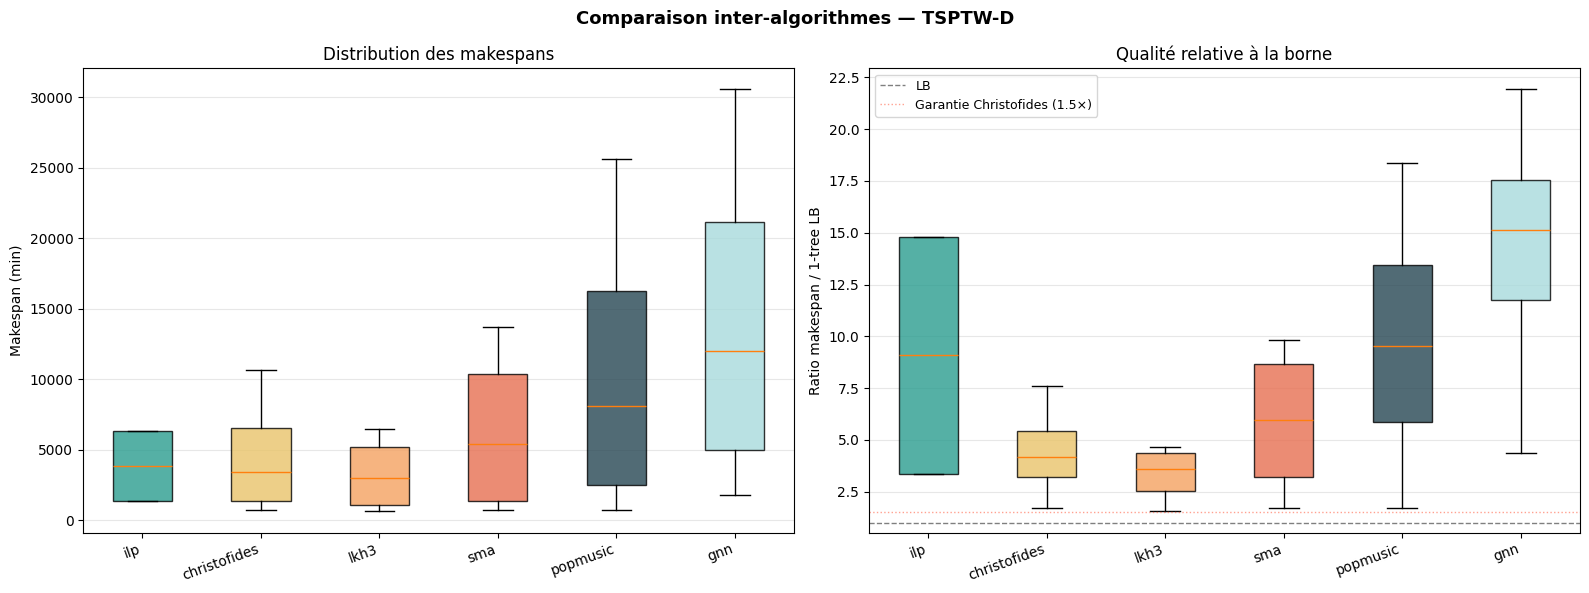

In [114]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

data_box  = [df_all.loc[df_all['algo']==a, 'makespan'].values for a in present]
bp = axes[0].boxplot(data_box, patch_artist=True)
for patch, algo in zip(bp['boxes'], present):
    patch.set_facecolor(ALGO_COLORS.get(algo,'gray')); patch.set_alpha(0.8)
axes[0].set_xticks(range(1,len(present)+1)); axes[0].set_xticklabels(present, rotation=20, ha='right')
axes[0].set_ylabel('Makespan (min)'); axes[0].set_title('Distribution des makespans'); axes[0].grid(axis='y',alpha=0.3)

data_ratio = [df_all.loc[df_all['algo']==a,'ratio_lb'].dropna().values for a in present]
bp2 = axes[1].boxplot(data_ratio, patch_artist=True)
for patch, algo in zip(bp2['boxes'], present):
    patch.set_facecolor(ALGO_COLORS.get(algo,'gray')); patch.set_alpha(0.8)
axes[1].axhline(1.0,color='k',linestyle='--',lw=1,alpha=0.5,label='LB')
axes[1].axhline(1.5,color='tomato',linestyle=':',lw=1,alpha=0.6,label='Garantie Christofides (1.5×)')
axes[1].set_xticks(range(1,len(present)+1)); axes[1].set_xticklabels(present,rotation=20,ha='right')
axes[1].set_ylabel('Ratio makespan / 1-tree LB'); axes[1].set_title('Qualité relative à la borne')
axes[1].legend(fontsize=9); axes[1].grid(axis='y',alpha=0.3)

plt.suptitle('Comparaison inter-algorithmes — TSPTW-D', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('docs/standalone_boxplot.png',dpi=130,bbox_inches='tight'); plt.show()

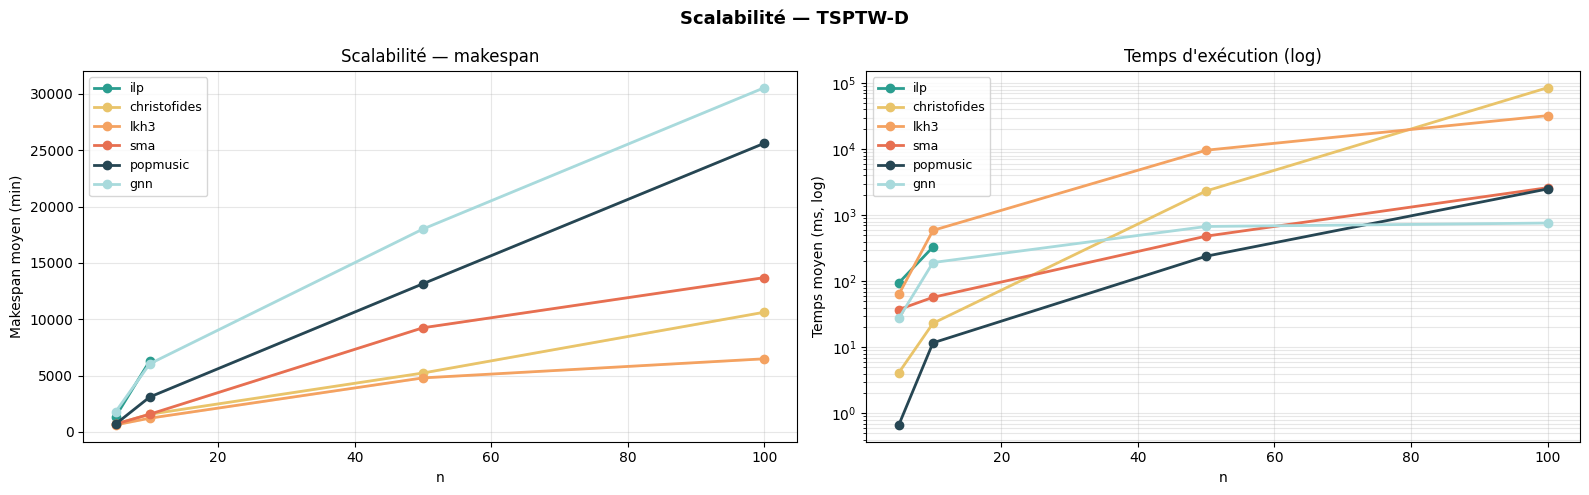

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for algo in present:
    sub = summary[summary['algo']==algo].sort_values('n')
    if sub.empty: continue
    c = ALGO_COLORS.get(algo,'gray')
    axes[0].plot(sub['n'], sub['makespan_mean'], 'o-', color=c, label=algo, lw=2)
    axes[0].fill_between(sub['n'],
                          sub['makespan_mean']-sub['makespan_std'].fillna(0),
                          sub['makespan_mean']+sub['makespan_std'].fillna(0), color=c, alpha=0.12)
axes[0].set_xlabel('n'); axes[0].set_ylabel('Makespan moyen (min)')
axes[0].set_title('Scalabilité — makespan'); axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

for algo in present:
    sub = summary[summary['algo']==algo].sort_values('n')
    if sub.empty: continue
    axes[1].semilogy(sub['n'], sub['time_ms_mean'], 'o-', color=ALGO_COLORS.get(algo,'gray'), label=algo, lw=2)
axes[1].set_xlabel('n'); axes[1].set_ylabel("Temps moyen (ms, log)")
axes[1].set_title("Temps d'exécution (log)"); axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3,which='both')

plt.suptitle('Scalabilité — TSPTW-D', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('docs/standalone_scalabilite.png',dpi=130,bbox_inches='tight'); plt.show()

---
## 8. Analyse statistique

In [116]:
print('=== Statistiques descriptives — makespan (min) ===')
desc = (df_all.groupby('algo')['makespan']
        .agg(N='count', Moy='mean', Méd='median', Std='std',
             MAD=lambda x: np.median(np.abs(x-x.median())), Min='min', Max='max')
        .round(1).reindex(present))
display(desc)

print('\n=== Ratio makespan / 1-tree LB ===')
display(df_all.groupby('algo')['ratio_lb']
        .agg(Moy='mean', Méd='median', Std='std').round(3).reindex(present))

print('\n=== Faisabilité (%) ===')
display(df_all.groupby('algo')['feasible'].mean().mul(100).round(1).reindex(present))

=== Statistiques descriptives — makespan (min) ===


,N,Moy,Méd,Std,MAD,Min,Max
algo,,,,,,,
ilp,6,3835.5,3835.5,2703.3,2467.8,1367.8,6303.3
christofides,12,4530.6,3400.6,4080.0,2265.1,698.4,10622.8
lkh3,12,3283.6,3008.0,2551.5,2083.3,628.0,6490.2
sma,12,6301.5,5407.2,5649.8,4271.6,698.4,13717.5
popmusic,12,10639.3,8122.7,10262.4,6223.3,698.4,25613.4
gnn,12,14093.3,12024.5,11702.4,8109.7,1782.0,30542.0



=== Ratio makespan / 1-tree LB ===


,Moy,Méd,Std
algo,,,
ilp,9.078,9.078,6.250
christofides,4.428,4.185,2.223
lkh3,3.341,3.578,1.287
sma,5.877,5.981,3.439
popmusic,9.784,9.520,6.376
gnn,14.151,15.150,6.591



=== Faisabilité (%) ===


algo
ilp              0.0
christofides     0.0
lkh3             0.0
sma              0.0
popmusic        25.0
gnn              0.0
Name: feasible, dtype: float64

In [117]:
print('=== Test de Wilcoxon pairwise (H₀ : distributions identiques, α=0.05) ===')
print(f'  {"Algo A":<15} {"Algo B":<15} {"N":>5} {"p-value":>10}  Sig.')
print('  '+'-'*50)
for a, b in combinations(present, 2):
    merged = pd.merge(
        df_all[df_all['algo']==a][['n','run','makespan']].rename(columns={'makespan':'ms_a'}),
        df_all[df_all['algo']==b][['n','run','makespan']].rename(columns={'makespan':'ms_b'}),
        on=['n','run'], how='inner')
    if len(merged) < 5: continue
    try:
        _, pval = stats.wilcoxon(merged['ms_a'], merged['ms_b'])
        sig = '✓' if pval < 0.05 else '✗'
        print(f'  {a:<15} {b:<15} {len(merged):>5}  {pval:>10.4f}  {sig}')
    except Exception: pass

=== Test de Wilcoxon pairwise (H₀ : distributions identiques, α=0.05) ===
  Algo A          Algo B              N    p-value  Sig.
  --------------------------------------------------
  ilp             christofides        6      0.0312  ✓
  ilp             lkh3                6      0.0312  ✓
  ilp             sma                 6      0.0312  ✓
  ilp             popmusic            6      0.0312  ✓
  ilp             gnn                 6      0.3438  ✗
  christofides    lkh3               12      0.0005  ✓
  christofides    sma                12      0.0312  ✓
  christofides    popmusic           12      0.0039  ✓
  christofides    gnn                12      0.0005  ✓
  lkh3            sma                12      0.0005  ✓
  lkh3            popmusic           12      0.0005  ✓
  lkh3            gnn                12      0.0005  ✓
  sma             popmusic           12      0.0039  ✓
  sma             gnn                12      0.0005  ✓
  popmusic        gnn                12      0

In [118]:
print('=== Classement par rang de Borda (rang 1 = meilleur) ===')
rank_rows=[]
for n in df_all['n'].unique():
    sub=df_all[df_all['n']==n].groupby('algo')['makespan'].mean()
    if len(sub)<2: continue
    for algo, rank in sub.rank().items():
        rank_rows.append({'n':n,'algo':algo,'rank':rank})
borda = pd.DataFrame(rank_rows).groupby('algo')['rank'].mean().sort_values().round(2)
display(borda.rename('Rang moyen (Borda)'))

=== Classement par rang de Borda (rang 1 = meilleur) ===


algo
lkh3            1.00
christofides    2.38
sma             2.88
popmusic        3.75
gnn             5.25
ilp             5.50
Name: Rang moyen (Borda), dtype: float64

---
## 9. Conclusion

### 9.1 Synthèse

| Algorithme | Points forts | Limites |
|------------|-------------|---------|
| **ILP** | Optimal pour $n \leq 10$–20 | Temps exponentiel |
| **Christofides** | Garantie 1.5× TSP pur, deterministe | Or-opt lent sur grands $n$, pas TW-optimal |
| **LKH-3 (ILK)** | Meilleure qualité toutes tailles | Temps croissant, pas de garantie théorique |
| **SMA** | Diversification via population | Très lent pour $n \geq 100$, attentes TW difficiles |
| **POPMUSIC** | Scalable, sous-problèmes indépendants | Qualité inférieure à LKH-3 |
| **GNN** | Inférence quasi-instantanée | Nécessite entraînement, sans garantie |

### 9.2 Interprétation du ratio 1-tree LB

Le ratio $\text{makespan} / \text{1-tree LB} > 1$ s'explique par deux composantes :
1. **Attentes obligatoires** aux fenêtres temporelles (inévitables, pas une dégradation)
2. **Sous-optimalité réelle** des heuristiques par rapport au transit pur

### 9.3 Perspectives

- **Hybridation** GNN (construction) + LKH-3 (raffinement)
- **Opérateurs TW-spécifiques** ciblant les clients à fenêtres manquées
- **Parallélisation** de POPMUSIC et SMA

### Références

- Karp (1972). *Reducibility Among Combinatorial Problems.*
- Christofides (1976). *Worst-case analysis for the TSP.*
- Helsgott et al. (2017). *LKH-3.* Computers & OR.
- Taillard & Voss (2002). *POPMUSIC.* Springer.
- Li et al. (2020). *Slime mould algorithm.* FGCS.
- Kool et al. (2019). *Attention, Learn to Solve Routing Problems.* ICLR.
- Solomon (1987). *Algorithms for VRPTW.* Operations Research.